# COMP 352 – Final Project: Footballer Market Evaluation  
**Goal:** Predict a footballer’s **market value next year** using **only historical information** (no future leakage).  

**Authors:** Zevin Attisha, Christian Vaikona, Santiago Guerrero, Santiago Pedetti   

**Dataset source:** https://www.kaggle.com/datasets/davidcariboo/player-scores  

---

## Table of Contents
1. Environment Setup  
2. Data Importing and Pre-processing  
3. Data Analysis and Visualization  
4. Data Analytics (Modeling)  
5. Summary / Conclusions  


## 1. Data Importing and Pre-processing (100 Points)
- Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
- Clean, wrangle, and handle missing data, duplicate data, etc.
- Encode any categorical variables
- Perform feature engineering on the dataset
- Transform data appropriately using techniques such as aggregation, normalization, and feature construction
- Reduce redundant data and perform need based discretization

We load two datasets:
- `player_valuations.csv`: multiple valuation records per player over time
- `players.csv`: one record per player with demographic and categorical info

We then clean data, engineer historical features, and build a **time-based target**: next year's market value.

## Environment Setup
This notebook uses common Python data science libraries (pandas, numpy, matplotlib, scikit-learn).

In [56]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from scipy import stats
from sklearn.model_selection import GridSearchCV 



pd.set_option("display.max_columns", None)
np.set_printoptions(suppress=True)

In [57]:
PATH_PLAYER_VALUATIONS = "data/raw/player_valuations.csv"
PATH_PLAYERS = "data/raw/players.csv"
PATH_APPEARANCES = "data/raw/appearances.csv"
PATH_LINEUPS = "data/raw/game_lineups.csv"  

player_valuations_df = pd.read_csv(PATH_PLAYER_VALUATIONS)
players_df = pd.read_csv(PATH_PLAYERS)
appearances_df = pd.read_csv(PATH_APPEARANCES)
lineups_df = pd.read_csv(PATH_LINEUPS)    

print("player_valuations_df shape:", player_valuations_df.shape)
print("players_df shape:", players_df.shape)
print("appearances_df shape:", appearances_df.shape)
print("lineups_df shape:", lineups_df.shape) 

print("player_valuations_df:")
display(player_valuations_df.head())

print("players_df:")
display(players_df.head())

print("appearances_df:")
display(appearances_df.head())

print("lineups_df:")
display(lineups_df.head())

# FOLLOWING ERROR COMES FROM REPO MANAGEMENT - ABOVE PATHS ASSUME THIS NOTEBOOK IS AT REPO ROOT
# RESULTS FOLLOWING THIS CODE CELL ARE CORRECT FOR ORIGINAL IMPLEMENTATION 


player_valuations_df shape: (496606, 5)
players_df shape: (32601, 23)
appearances_df shape: (1706806, 13)
lineups_df shape: (2191911, 10)
player_valuations_df:


,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


players_df:


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,1978-06-09 00:00:00,Centre-Forward,Attack,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,1980-08-06 00:00:00,Goalkeeper,Goalkeeper,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,1981-01-30 00:00:00,Centre-Forward,Attack,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,1978-05-08 00:00:00,Centre-Back,Defender,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,1981-03-18 00:00:00,Goalkeeper,Goalkeeper,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


appearances_df:


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


lineups_df:


,game_lineups_id,date,game_id,player_id,club_id,player_name,type,position,number,team_captain
0,b2dbe01c3656b06c8e23e9de714e26bb,2013-07-27,2317258,1443,610,Christian Poulsen,substitutes,Defensive Midfield,5,0
1,b50a3ec6d52fd1490aab42042ac4f738,2013-07-27,2317258,5017,610,Niklas Moisander,starting_lineup,Centre-Back,4,0
2,7d890e6d0ff8af84b065839966a0ec81,2013-07-27,2317258,9602,1090,Maarten Martens,substitutes,Left Winger,11,0
3,8c355268678b9bbc7084221b1f0fde36,2013-07-27,2317258,12282,610,Daley Blind,starting_lineup,Left-Back,17,0
4,76193074d549e5fdce4cdcbba0d66247,2013-07-27,2317258,25427,1090,Roy Beerens,starting_lineup,Right Winger,23,0


In [58]:
# ===== Duplicate Check =====
print("=" * 60)
print("=== Duplicate Data Check ===")
print("=" * 60)

print("\nPlayer Valuations Dataset:")
print(f"Total rows: {len(player_valuations_df)}")
print(f"Duplicate rows: {player_valuations_df.duplicated().sum()}")
if player_valuations_df.duplicated().sum() > 0:
    print(f"Removing {player_valuations_df.duplicated().sum()} duplicate rows...")
    player_valuations_df = player_valuations_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(player_valuations_df)}")
else:
    print("No duplicate rows found.")

print("\nPlayers Dataset:")
print(f"Total rows: {len(players_df)}")
print(f"Duplicate rows: {players_df.duplicated().sum()}")
if players_df.duplicated().sum() > 0:
    print(f"Removing {players_df.duplicated().sum()} duplicate rows...")
    players_df = players_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(players_df)}")
else:
    print("No duplicate rows found.")

=== Duplicate Data Check ===

Player Valuations Dataset:
Total rows: 496606
Duplicate rows: 0
No duplicate rows found.

Players Dataset:
Total rows: 32601
Duplicate rows: 0
No duplicate rows found.


In [59]:

print("player_valuations_df dtypes:")
display(player_valuations_df.dtypes)

print("\nplayers_df dtypes:")
display(players_df.dtypes)

print("\nappearances_df dtypes:")
display(appearances_df.dtypes)

# Columns that display the most missing values in descending order

print("\nMissing values (top 10) - player_valuations_df:")
display(player_valuations_df.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values (top 10) - players_df:")
display(players_df.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values - appearances_df:")
display(appearances_df.isna().sum())
print("\nSample of appearances data:")
display(appearances_df.head(10))


player_valuations_df dtypes:


player_id                               int64
date                                   object
market_value_in_eur                     int64
current_club_id                         int64
player_club_domestic_competition_id    object
dtype: object


players_df dtypes:


player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
url                                      object
current_club_domestic_competition_id     object
current_club_name                       


appearances_df dtypes:


...

agent_name                     16019
contract_expiration_date       12091
country_of_birth                2799
foot                            2536
city_of_birth                   2455
height_in_cm                    2256
first_name                      2062
highest_market_value_in_eur     1523
market_value_in_eur             1523
country_of_citizenship           383
dtype: int64


Missing values - appearances_df:


appearance_id             0
game_id                   0
player_id                 0
player_club_id            0
player_current_club_id    0
date                      0
player_name               6
competition_id            0
yellow_cards              0
red_cards                 0
goals                     0
assists                   0
minutes_played            0
dtype: int64


Sample of appearances data:


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90
5,2234421_146889,2234421,146889,195,2778,2012-07-05,Peter Ankersen,ELQ,1,0,0,0,90
6,2235539_28716,2235539,28716,282,7185,2012-07-05,Adi Adilovic,ELQ,0,0,0,0,90
7,2235539_69445,2235539,69445,282,19771,2012-07-05,Ivan Sesar,ELQ,1,0,0,1,90
8,2235545_19409,2235545,19409,317,200,2012-07-05,Willem Janssen,ELQ,0,0,0,0,45
9,2235545_30003,2235545,30003,317,317,2012-07-05,Wout Brama,ELQ,0,0,0,0,90


In [60]:
# Clean appearances data
app = appearances_df.copy()

# Parse date to datetime
app['date'] = pd.to_datetime(app['date'], errors='coerce')
app = app.dropna(subset=['date'])

# Extract year from match date
app['year'] = app['date'].dt.year

# Fill missing performance stats with 0 (player appeared but didn't score/assist)
app['goals'] = app['goals'].fillna(0)
app['assists'] = app['assists'].fillna(0)
app['minutes_played'] = app['minutes_played'].fillna(0)
app['yellow_cards'] = app['yellow_cards'].fillna(0)
app['red_cards'] = app['red_cards'].fillna(0)

print("app shape after cleaning:", app.shape)
print("\nSample:")
display(app[['player_id', 'date', 'year', 'goals', 'assists', 'minutes_played']].head(10))

app shape after cleaning: (1706806, 14)

Sample:


,player_id,date,year,goals,assists,minutes_played
0,38004,2012-07-03,2012,2,0,90
1,79232,2012-07-05,2012,0,0,90
2,42792,2012-07-05,2012,0,0,45
3,73333,2012-07-05,2012,0,0,90
4,122011,2012-07-05,2012,0,1,90
5,146889,2012-07-05,2012,0,0,90
6,28716,2012-07-05,2012,0,0,90
7,69445,2012-07-05,2012,0,1,90
8,19409,2012-07-05,2012,0,0,45
9,30003,2012-07-05,2012,0,0,90


In [61]:
print("="*80)
print("CREATING LIFETIME CUMULATIVE PERFORMANCE STATISTICS ")
print("="*80)

app = appearances_df.copy()

# Parse date to datetime
app['date'] = pd.to_datetime(app['date'], errors='coerce')
app = app.dropna(subset=['date'])

# Fill missing performance stats with 0 (player appeared but didn't score/assist)
app['goals'] = app['goals'].fillna(0)
app['assists'] = app['assists'].fillna(0)
app['minutes_played'] = app['minutes_played'].fillna(0)
app['yellow_cards'] = app['yellow_cards'].fillna(0)
app['red_cards'] = app['red_cards'].fillna(0)

# Sort by player and date
app = app.sort_values(['player_id', 'date']).reset_index(drop=True)

print("\nCalculating LIFETIME cumulative statistics...")
print("  (Each player's cumulative stats span their entire career)")

app['cumulative_goals'] = app.groupby(['player_id'])['goals'].cumsum()
app['cumulative_assists'] = app.groupby(['player_id'])['assists'].cumsum()
app['cumulative_minutes'] = app.groupby(['player_id'])['minutes_played'].cumsum()
app['cumulative_yellows'] = app.groupby(['player_id'])['yellow_cards'].cumsum()
app['cumulative_reds'] = app.groupby(['player_id'])['red_cards'].cumsum()
app['cumulative_appearances'] = app.groupby(['player_id']).cumcount() + 1

# Keep only the most recent row per player per date (in case multiple games same day)
app_cumulative = app.groupby(['player_id', 'date']).tail(1).reset_index(drop=True)

# Select columns for merge
app_for_merge = app_cumulative[[
    'player_id', 'date',
    'cumulative_goals', 'cumulative_assists', 'cumulative_minutes',
    'cumulative_yellows', 'cumulative_reds', 'cumulative_appearances'
]].copy()

print(f"\n app_for_merge shape: {app_for_merge.shape}")
print(f" Date range: {app_for_merge['date'].min()} to {app_for_merge['date'].max()}")
print(f" Unique players: {app_for_merge['player_id'].nunique()}")

# Verify cumulative logic is working correctly
print("\n Verification - checking cumulative growth for a sample player:")
sample_player_id = app_for_merge['player_id'].iloc[100] if len(app_for_merge) > 100 else app_for_merge['player_id'].iloc[0]
sample_data = app_for_merge[app_for_merge['player_id'] == sample_player_id].head(10)
print(f"\nPlayer ID: {sample_player_id}")
print("Notice how cumulative_goals increases over time (lifetime cumulative):")
display(sample_data[['date', 'cumulative_goals', 'cumulative_assists', 'cumulative_minutes', 'cumulative_appearances']])

print("\n" + "="*80)
print("PERFORMANCE DATA PREPARED")
print("="*80)

CREATING LIFETIME CUMULATIVE PERFORMANCE STATISTICS 

Calculating LIFETIME cumulative statistics...
  (Each player's cumulative stats span their entire career)

 app_for_merge shape: (1706792, 8)
 Date range: 2012-07-03 00:00:00 to 2025-04-10 00:00:00
 Unique players: 25689

 Verification - checking cumulative growth for a sample player:

Player ID: 10
Notice how cumulative_goals increases over time (lifetime cumulative):


,date,cumulative_goals,cumulative_assists,cumulative_minutes,cumulative_appearances
0,2012-08-23,1,0,83,1
1,2012-08-26,1,0,173,2
2,2012-09-02,3,0,262,3
3,2012-09-16,4,0,352,4
4,2012-09-20,4,0,442,5
5,2012-09-23,4,0,456,6
6,2012-09-26,4,0,546,7
7,2012-09-30,4,1,636,8
8,2012-10-07,6,1,708,9
9,2012-10-20,7,1,798,10



PERFORMANCE DATA PREPARED


We keep only the columns needed for modeling and remove columns that are not useful or could cause leakage (e.g., current market value fields in `players.csv`).

In [62]:
pv = player_valuations_df.copy()

# Parse date
pv["date"] = pd.to_datetime(pv["date"], errors="coerce")
pv = pv.dropna(subset=["date"])

# Remove duplicates (same player_id & date)
pv = pv.drop_duplicates(subset=["player_id", "date"], keep="last")

# Keep essential columns
pv = pv[[
    "player_id",
    "date",
    "market_value_in_eur",
    "current_club_id",
    "player_club_domestic_competition_id"
]].copy()

# Rename for clarity
pv = pv.rename(columns={
    "market_value_in_eur": "market_value_in_eur_valuation",
    "current_club_id": "current_club_id_valuation",
    "player_club_domestic_competition_id": "domestic_competition_id_valuation"
})

print("pv shape:", pv.shape)
pv.head()


pv shape: (496606, 5)


,player_id,date,market_value_in_eur_valuation,current_club_id_valuation,domestic_competition_id_valuation
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [63]:
# Clean players (p)

p = players_df.copy()

# Parse birth date
p["date_of_birth"] = pd.to_datetime(p["date_of_birth"], errors="coerce")

# Keep only safe player-level features (no leakage)
keep_player_cols = [
    "player_id",
    "date_of_birth",
    "position",
    "sub_position",
    "foot",
    "height_in_cm"
]
p = p[keep_player_cols].copy()

# Handle missing categoricals
p["position"] = p["position"].fillna("Missing")
p["sub_position"] = p["sub_position"].fillna("Missing")
p["foot"] = p["foot"].fillna("Missing")

# Numeric height + impute
p["height_in_cm"] = pd.to_numeric(p["height_in_cm"], errors="coerce")
p["height_in_cm"] = p["height_in_cm"].fillna(p["height_in_cm"].median())

# Birth date required for age feature
p = p.dropna(subset=["date_of_birth"])

print("p shape:", p.shape)
p.head()


p shape: (32554, 6)


,player_id,date_of_birth,position,sub_position,foot,height_in_cm
0,10,1978-06-09,Attack,Centre-Forward,right,184.0
1,26,1980-08-06,Goalkeeper,Goalkeeper,left,190.0
2,65,1981-01-30,Attack,Centre-Forward,Missing,183.0
3,77,1978-05-08,Defender,Centre-Back,Missing,183.0
4,80,1981-03-18,Goalkeeper,Goalkeeper,right,194.0


We merge valuation records with player info using `player_id`. Each valuation row becomes a modeling row with player features attached.

In [64]:
# ========== Merge player valuations with player info ==========
merged_df = pv.merge(p, on="player_id", how="left")

# Drop valuation rows missing player info
merged_df = merged_df.dropna(subset=["date_of_birth"])

print("merged_df shape:", merged_df.shape)
merged_df.head()


# ========== Yearly snapshots (1 row per player per year) ==========

# Ensure datetime for valuation date
merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")
merged_df = merged_df.dropna(subset=["date"])

# Create a year column
merged_df["year"] = merged_df["date"].dt.year

# Keep only the last valuation within each year per player
merged_df = (
    merged_df.sort_values(["player_id", "date"])
             .groupby(["player_id", "year"], as_index=False)
             .tail(1)
             .reset_index(drop=True)
)

print("merged_df shape after yearly snapshot:", merged_df.shape)
merged_df[["player_id", "date", "year", "market_value_in_eur_valuation"]].head()


# ========== Manual merge_asof by player ==========
print("\n" + "="*80)
print("MERGING PERFORMANCE STATISTICS WITH TEMPORAL INTEGRITY")
print("Using manual player-by-player merge (more reliable)")
print("="*80)

# ==========  NaN player_id ==========
print("="*60)
print("FIXING NaN player_id VALUES")
print("="*60)

# Diagnostic
print(f"\nBefore cleaning:")
print(f"  Total rows: {len(merged_df)}")
print(f"  NaN player_ids: {merged_df['player_id'].isna().sum()}")

# Remove rows with NaN player_id
merged_df = merged_df.dropna(subset=['player_id'])

print(f"\nAfter cleaning:")
print(f"  Total rows: {len(merged_df)}")
print(f"  NaN player_ids: {merged_df['player_id'].isna().sum()}")
print("="*60 + "\n")
# ========================================

# Ensure data types
merged_df['player_id'] = merged_df['player_id'].astype(int)
app_for_merge['player_id'] = app_for_merge['player_id'].astype(int)
merged_df['date'] = pd.to_datetime(merged_df['date'])
app_for_merge['date'] = pd.to_datetime(app_for_merge['date'])

# Sort data
merged_df = merged_df.sort_values(['player_id', 'date']).reset_index(drop=True)
app_for_merge = app_for_merge.sort_values(['player_id', 'date']).reset_index(drop=True)

print(f"Starting merge for {merged_df['player_id'].nunique()} unique players...")
print(f"This may take 1-2 minutes...\n")

# Manual merge by player
result_list = []
unique_players = merged_df['player_id'].unique()

import time
start_time = time.time()

for i, pid in enumerate(unique_players):
    # Progress indicator every 1000 players
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i+1}/{len(unique_players)} players ({elapsed:.1f}s elapsed)...")
    
    # Get data for this player
    player_val = merged_df[merged_df['player_id'] == pid].copy()
    player_app = app_for_merge[app_for_merge['player_id'] == pid].copy()
    
    # Merge with appearances data if available
    if len(player_app) > 0:
        player_merged = pd.merge_asof(
            player_val.sort_values('date'),
            player_app.sort_values('date'),
            on='date',
            direction='backward',
            tolerance=pd.Timedelta(days=90),
            allow_exact_matches=True
        )
    else:
        # No appearance data for this player - keep valuation data with NaN performance
        player_merged = player_val
    
    result_list.append(player_merged)

# Combine all players
merged_df = pd.concat(result_list, ignore_index=True)

elapsed_total = time.time() - start_time
print(f"\n Merge complete in {elapsed_total:.1f} seconds!")
print(f"Final merged_df shape: {merged_df.shape}")
print(f"Rows with performance data: {merged_df['cumulative_goals'].notna().sum()}")
print(f"Rows without performance data: {merged_df['cumulative_goals'].isna().sum()}")

# Rename cumulative columns
merged_df = merged_df.rename(columns={
    'cumulative_goals': 'total_goals',
    'cumulative_assists': 'total_assists',
    'cumulative_minutes': 'total_minutes',
    'cumulative_yellows': 'total_yellow_cards',
    'cumulative_reds': 'total_red_cards',
    'cumulative_appearances': 'num_appearances'
})

# Fill NaNs (players with no appearances before valuation date)
perf_cols = ['total_goals', 'total_assists', 'total_minutes', 'num_appearances',
             'total_yellow_cards', 'total_red_cards']
for col in perf_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(0)

# Calculate per-90 stats
print("\nCalculating per-90 minute statistics...")
merged_df['goals_per_90'] = np.where(
    merged_df['total_minutes'] > 0,
    (merged_df['total_goals'] / merged_df['total_minutes']) * 90,
    0
)
merged_df['assists_per_90'] = np.where(
    merged_df['total_minutes'] > 0,
    (merged_df['total_assists'] / merged_df['total_minutes']) * 90,
    0
)
merged_df['goal_contributions_per_90'] = merged_df['goals_per_90'] + merged_df['assists_per_90']
merged_df['games_started_estimate'] = merged_df['total_minutes'] / 90
merged_df['cards_per_90'] = np.where(
    merged_df['total_minutes'] > 0,
    ((merged_df['total_yellow_cards'] + merged_df['total_red_cards'] * 2) / merged_df['total_minutes']) * 90,
    0
)


print(f"\nPerformance statistics merged with NO TEMPORAL LEAKAGE")
print(f"Final shape: {merged_df.shape}")
print("\nSample with performance features:")
display(merged_df[['player_id', 'date', 'year', 'market_value_in_eur_valuation', 
                    'total_goals', 'total_assists', 'total_minutes', 'goals_per_90']].head(10))

print(f"\nPerformance statistics merged with NO TEMPORAL LEAKAGE")
print(f"Final shape: {merged_df.shape}")
print("\nSample with performance features:")
display(merged_df[['player_id', 'date', 'year', 'market_value_in_eur_valuation', 
                    'total_goals', 'total_assists', 'total_minutes', 'goals_per_90']].head(10))

# Safe verification - check if ANY players have performance data
players_with_perf = merged_df[merged_df['total_goals'] > 0]
if len(players_with_perf) > 0:
    print(f"\n Verification - found {len(players_with_perf)} observations with goals > 0:")
    sample_player_id = players_with_perf['player_id'].iloc[0]
    sample_player = merged_df[merged_df['player_id'] == sample_player_id].head(5)
    display(sample_player[['player_id', 'date', 'year', 'total_goals', 'total_assists', 'total_minutes']])
else:
    print(f"\n No players have goals > 0 in current dataset")
    print(f"This may indicate:")
    print(f"  1. Valuations are from before appearance data starts (2012)")
    print(f"  2. Tolerance window (365 days) may need adjustment")
    print(f"  3. Player IDs may not match between datasets")
    
    # Show date ranges
    print(f"\nDate ranges:")
    print(f"  Valuations: {merged_df['date'].min()} to {merged_df['date'].max()}")
    print(f"  Appearances: {app_for_merge['date'].min()} to {app_for_merge['date'].max()}")

merged_df shape: (496045, 10)
merged_df shape after yearly snapshot: (251792, 11)

MERGING PERFORMANCE STATISTICS WITH TEMPORAL INTEGRITY
Using manual player-by-player merge (more reliable)
FIXING NaN player_id VALUES

Before cleaning:
  Total rows: 251792
  NaN player_ids: 0

After cleaning:
  Total rows: 251792
  NaN player_ids: 0

Starting merge for 31046 unique players...
This may take 1-2 minutes...

Processed 1000/31046 players (1.2s elapsed)...
Processed 2000/31046 players (2.5s elapsed)...
Processed 3000/31046 players (3.7s elapsed)...
Processed 4000/31046 players (4.9s elapsed)...
Processed 5000/31046 players (6.4s elapsed)...
Processed 6000/31046 players (7.6s elapsed)...
Processed 7000/31046 players (8.8s elapsed)...
Processed 8000/31046 players (10.0s elapsed)...
Processed 9000/31046 players (11.4s elapsed)...
Processed 10000/31046 players (12.7s elapsed)...
Processed 11000/31046 players (13.8s elapsed)...
Processed 12000/31046 players (15.0s elapsed)...
Processed 13000/310

,player_id,date,year,market_value_in_eur_valuation,total_goals,total_assists,total_minutes,goals_per_90
0,NaN,2004-10-04,2004,7000000,0.0,0.0,0.0,0.00000
1,NaN,2005-09-30,2005,15000000,0.0,0.0,0.0,0.00000
2,NaN,2006-07-15,2006,30000000,0.0,0.0,0.0,0.00000
3,NaN,2007-06-21,2007,23000000,0.0,0.0,0.0,0.00000
4,NaN,2008-06-04,2008,20000000,0.0,0.0,0.0,0.00000
5,NaN,2009-08-30,2009,12000000,0.0,0.0,0.0,0.00000
6,NaN,2010-05-08,2010,7500000,0.0,0.0,0.0,0.00000
7,NaN,2011-06-29,2011,5000000,0.0,0.0,0.0,0.00000
8,NaN,2012-07-03,2012,6000000,0.0,0.0,0.0,0.00000
9,NaN,2013-06-19,2013,2000000,16.0,3.0,2585.0,0.55706



Performance statistics merged with NO TEMPORAL LEAKAGE
Final shape: (251792, 24)

Sample with performance features:


,player_id,date,year,market_value_in_eur_valuation,total_goals,total_assists,total_minutes,goals_per_90
0,NaN,2004-10-04,2004,7000000,0.0,0.0,0.0,0.00000
1,NaN,2005-09-30,2005,15000000,0.0,0.0,0.0,0.00000
2,NaN,2006-07-15,2006,30000000,0.0,0.0,0.0,0.00000
3,NaN,2007-06-21,2007,23000000,0.0,0.0,0.0,0.00000
4,NaN,2008-06-04,2008,20000000,0.0,0.0,0.0,0.00000
5,NaN,2009-08-30,2009,12000000,0.0,0.0,0.0,0.00000
6,NaN,2010-05-08,2010,7500000,0.0,0.0,0.0,0.00000
7,NaN,2011-06-29,2011,5000000,0.0,0.0,0.0,0.00000
8,NaN,2012-07-03,2012,6000000,0.0,0.0,0.0,0.00000
9,NaN,2013-06-19,2013,2000000,16.0,3.0,2585.0,0.55706



 Verification - found 48012 observations with goals > 0:


,player_id,date,year,total_goals,total_assists,total_minutes


In [65]:
print("="*80)
print("CHECKING DATA BEFORE/AFTER LINEUPS MERGE")
print("="*80)

# This should show your current state
print(f"Current merged_df shape: {merged_df.shape}")
print(f"Players with goals > 0: {(merged_df['total_goals'] > 0).sum()}")
print(f"Players with minutes > 0: {(merged_df['total_minutes'] > 0).sum()}")

# Check if you accidentally filtered your data
print(f"\nDate range in current data:")
print(f"  Min: {merged_df['date'].min()}")
print(f"  Max: {merged_df['date'].max()}")
print(f"  Unique years: {sorted(merged_df['year'].unique())}")

CHECKING DATA BEFORE/AFTER LINEUPS MERGE
Current merged_df shape: (251792, 24)
Players with goals > 0: 48012
Players with minutes > 0: 69253

Date range in current data:
  Min: 2000-01-20 00:00:00
  Max: 2025-04-06 00:00:00
  Unique years: [np.int32(2000), np.int32(2001), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


We compute age at valuation date and create historical features (lags, trends, rolling mean). We also build the target: next year's market value.

In [66]:
print("\n" + "="*80)
print("PROCESSING LINEUP DATA WITH TEMPORAL INTEGRITY")
print("="*80)

# Ensure datetime
lineups_df["date"] = pd.to_datetime(lineups_df["date"], errors="coerce")
lineups_df = lineups_df.dropna(subset=["date"])

# Identify starts from 'type'
lineups_df["is_start"] = (
    lineups_df["type"]
    .astype(str)
    .str.lower()
    .str.contains("start", na=False)
)

# Ensure captain flag is numeric
lineups_df["team_captain"] = lineups_df["team_captain"].fillna(0).astype(int)

# Sort by player and date
lineups_df = lineups_df.sort_values(['player_id', 'date']).reset_index(drop=True)

print("\nCalculating LIFETIME cumulative lineup statistics...")
print("  (Each player's lineup stats span their entire career)")

# Create cumulative counts by player-year
lineups_df['cumulative_matches'] = lineups_df.groupby(['player_id']).cumcount() + 1
lineups_df['cumulative_starts'] = lineups_df.groupby(['player_id'])['is_start'].cumsum()
lineups_df['cumulative_captain'] = lineups_df.groupby(['player_id'])['team_captain'].cumsum()

# Keep most recent row per player-date (in case of multiple games same day)
lineups_cumulative = lineups_df.groupby(['player_id', 'date']).tail(1).reset_index(drop=True)

# Select columns for merge
lineups_for_merge = lineups_cumulative[[
    'player_id', 'date',
    'cumulative_matches', 'cumulative_starts', 'cumulative_captain'
]].copy()

print(f"Prepared lineup data: {lineups_for_merge.shape}")
print("Starting player-by-player merge...")

# Drop old lineup columns if they exist (from previous run)
lineup_cols_to_drop = ['lineup_matches', 'starts', 'captain_matches', 'start_ratio']
for col in lineup_cols_to_drop:
    if col in merged_df.columns:
        merged_df = merged_df.drop(columns=[col])
        print(f"Dropped existing column: {col}")

# fix FOR NaN player_id

print("\n" + "="*80)
print("COMPREHENSIVE PLAYER_ID DIAGNOSTIC AND FIX")
print("="*80)

# Check what columns we have
print("\n1. Current columns in merged_df:")
player_cols = [c for c in merged_df.columns if 'player' in c.lower() and 'id' in c.lower()]
print(f"   Player ID columns found: {player_cols}")

# SCheck each column for issues
for col in player_cols:
    print(f"\n2. Analyzing {col}:")
    print(f"   - Type: {merged_df[col].dtype}")
    print(f"   - Total values: {len(merged_df[col])}")
    print(f"   - NaN count: {merged_df[col].isna().sum()}")
    print(f"   - Inf count: {np.isinf(merged_df[col].fillna(0)).sum()}")
    print(f"   - Unique values: {merged_df[col].nunique()}")
    if merged_df[col].notna().any():
        print(f"   - Sample non-NaN values: {merged_df[col].dropna().head(3).tolist()}")

# Fix duplicate player_id columns if they exist
if len(player_cols) > 1:
    print(f"\n3. Multiple player_id columns detected - consolidating...")
    
    # Use the first non-NaN value across all player_id columns
    merged_df['player_id_fixed'] = merged_df[player_cols[0]]
    
    for col in player_cols[1:]:
        merged_df['player_id_fixed'] = merged_df['player_id_fixed'].fillna(merged_df[col])
    
    # Drop all old player_id columns
    merged_df = merged_df.drop(columns=player_cols)
    
    # Rename to player_id
    merged_df = merged_df.rename(columns={'player_id_fixed': 'player_id'})
    
    print(f"   Consolidated {len(player_cols)} columns into one")
    print(f"   - NaN count after consolidation: {merged_df['player_id'].isna().sum()}")

#More aggressive cleaning
print("\n4. Cleaning player_id column:")
print(f"   Before: {len(merged_df)} rows")

# Remove NaN
merged_df = merged_df[merged_df['player_id'].notna()].copy()
print(f"   After removing NaN: {len(merged_df)} rows")

# Remove Inf
if merged_df['player_id'].dtype == 'float64':
    merged_df = merged_df[~np.isinf(merged_df['player_id'])].copy()
    print(f"   After removing Inf: {len(merged_df)} rows")

# Remove negative values (player IDs should be positive)
merged_df = merged_df[merged_df['player_id'] > 0].copy()
print(f"   After removing non-positive: {len(merged_df)} rows")

# Final verification
print("\n5. Final verification before conversion:")
print(f"   - Total rows: {len(merged_df)}")
print(f"   - NaN count: {merged_df['player_id'].isna().sum()}")
print(f"   - Inf count: {np.isinf(merged_df['player_id']).sum()}")
print(f"   - Min value: {merged_df['player_id'].min()}")
print(f"   - Max value: {merged_df['player_id'].max()}")
print(f"   - Data type: {merged_df['player_id'].dtype}")

# Safe conversion to int
try:
    # First convert to nullable Int64 which handles edge cases better
    merged_df['player_id'] = pd.to_numeric(merged_df['player_id'], errors='coerce')
    merged_df = merged_df[merged_df['player_id'].notna()].copy()
    merged_df['player_id'] = merged_df['player_id'].astype('Int64')
    print("\n   Successfully converted to Int64")
except Exception as e:
    print(f"\n   Error: {e}")
    print("   Attempting alternative conversion...")
    
    # Alternative: round first, then convert
    merged_df['player_id'] = merged_df['player_id'].round(0)
    merged_df['player_id'] = merged_df['player_id'].astype(int)
    print("   Successfully converted using alternative method")

print(f"\n6. After conversion:")
print(f"   - Data type: {merged_df['player_id'].dtype}")
print(f"   - Sample values: {merged_df['player_id'].head(5).tolist()}")

# Also fix lineups_for_merge
print("\n7. Fixing lineups_for_merge player_id:")
lineups_for_merge = lineups_for_merge[lineups_for_merge['player_id'].notna()].copy()
lineups_for_merge['player_id'] = pd.to_numeric(lineups_for_merge['player_id'], errors='coerce')
lineups_for_merge = lineups_for_merge[lineups_for_merge['player_id'].notna()].copy()
lineups_for_merge['player_id'] = lineups_for_merge['player_id'].astype('Int64')
print(f"   lineups_for_merge player_id fixed")

print("="*80)
print("PLAYER_ID CONVERSION COMPLETE - READY FOR MERGE")
print("="*80 + "\n")


# Manual merge by player
import time
start_time = time.time()

result_list = []
unique_players = merged_df['player_id'].unique()

print(f"Starting merge for {len(unique_players)} unique players...")

for i, pid in enumerate(unique_players):
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i+1}/{len(unique_players)} players ({elapsed:.1f}s elapsed)...")
    
    player_val = merged_df[merged_df['player_id'] == pid].copy()
    player_lineup = lineups_for_merge[lineups_for_merge['player_id'] == pid].copy()
    
    if len(player_lineup) > 0:
        # Drop player_id before merge_asof to avoid duplication
        player_lineup_for_asof = player_lineup[['date', 'cumulative_matches', 
                                                 'cumulative_starts', 'cumulative_captain']].copy()
        
        player_merged = pd.merge_asof(
            player_val.sort_values('date'),
            player_lineup_for_asof.sort_values('date'),
            on='date',
            direction='backward',
            tolerance=pd.Timedelta(days=90),  
            allow_exact_matches=True
        )
    else:
        player_merged = player_val
    
    result_list.append(player_merged)

merged_df = pd.concat(result_list, ignore_index=True)

elapsed_total = time.time() - start_time
print(f"\nLineup merge complete in {elapsed_total:.1f} seconds!")
print(f"Final shape: {merged_df.shape}")
print(f"Unique players: {merged_df['player_id'].nunique()}")


# Verification
print("\n" + "="*80)
print("VERIFICATION")
print("="*80)

player_id_cols_after = [c for c in merged_df.columns if 'player' in c.lower() and 'id' in c.lower()]
print(f"\nPlayer ID columns after merge: {player_id_cols_after}")

if len(player_id_cols_after) == 1 and player_id_cols_after[0] == 'player_id':
    print("Single clean player_id column")
else:
    print(f"WARNING: Found {len(player_id_cols_after)} player_id columns: {player_id_cols_after}")

# Check for NaN player_ids
print(f"\nNaN player_ids: {merged_df['player_id'].isna().sum()}")

# Rename and fill lineup columns
print("\n" + "="*80)
print("FINALIZING LINEUP FEATURES")
print("="*80)

# Rename cumulative columns
rename_map = {
    'cumulative_matches': 'lineup_matches',
    'cumulative_starts': 'starts',
    'cumulative_captain': 'captain_matches'
}
cols_to_rename = {k: v for k, v in rename_map.items() if k in merged_df.columns}
if cols_to_rename:
    merged_df = merged_df.rename(columns=cols_to_rename)
    print(f"Renamed columns: {list(cols_to_rename.values())}")

# Fill NaNs
for c in ["lineup_matches", "starts", "captain_matches"]:
    if c in merged_df.columns:
        merged_df[c] = merged_df[c].fillna(0)

# Calculate start ratio
if 'lineup_matches' in merged_df.columns and 'starts' in merged_df.columns:
    merged_df['start_ratio'] = np.where(
        merged_df['lineup_matches'] > 0,
        merged_df['starts'] / merged_df['lineup_matches'],
        0
    )
    merged_df['start_ratio'] = merged_df['start_ratio'].fillna(0)

print(f"\nLineup features added successfully")
print(f"Final merged_df shape: {merged_df.shape}")
print(f"Rows with lineup data: {(merged_df.get('lineup_matches', pd.Series([0])) > 0).sum()}")


PROCESSING LINEUP DATA WITH TEMPORAL INTEGRITY

Calculating LIFETIME cumulative lineup statistics...
  (Each player's lineup stats span their entire career)
Prepared lineup data: (2191895, 5)
Starting player-by-player merge...

COMPREHENSIVE PLAYER_ID DIAGNOSTIC AND FIX

1. Current columns in merged_df:
   Player ID columns found: ['player_id_x', 'player_id_y', 'player_id']

2. Analyzing player_id_x:
   - Type: float64
   - Total values: 251792
   - NaN count: 26898
   - Inf count: 0
   - Unique values: 25304
   - Sample non-NaN values: [10.0, 10.0, 10.0]

2. Analyzing player_id_y:
   - Type: float64
   - Total values: 251792
   - NaN count: 182539
   - Inf count: 0
   - Unique values: 20753
   - Sample non-NaN values: [10.0, 10.0, 10.0]

2. Analyzing player_id:
   - Type: float64
   - Total values: 251792
   - NaN count: 224894
   - Inf count: 0
   - Unique values: 5742
   - Sample non-NaN values: [162.0, 162.0, 162.0]

3. Multiple player_id columns detected - consolidating...
   Con

In [67]:

# Feature Engineering (time series per player, yearly)
# At this point, merged_df has ONE row per player per year (yearly snapshot).
# We now compute age, create a next-year target, and build historical lag features.

merged_df = merged_df.sort_values(["date","player_id"]).reset_index(drop=True)

# Age at time of valuation
merged_df["age_at_valuation"] = ((merged_df["date"] - merged_df["date_of_birth"]).dt.days / 365.25)


# Target: next year's value (t+1 year)
merged_df["market_value_next_year"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(-1)
)

# Historical lags (past only)
merged_df["market_value_lag_1"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(1)
)
merged_df["market_value_lag_2"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(2)
)

# Dynamics
merged_df["market_value_trend"] = merged_df["market_value_lag_1"] - merged_df["market_value_lag_2"]

# Rolling mean (past only) - use shift(1) then rolling window
merged_df["market_value_mean_3"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Create performance lag features (historical performance)
merged_df['goals_lag_1'] = merged_df.groupby('player_id')['total_goals'].shift(1)
merged_df['assists_lag_1'] = merged_df.groupby('player_id')['total_assists'].shift(1)
merged_df['minutes_lag_1'] = merged_df.groupby('player_id')['total_minutes'].shift(1)
merged_df['goals_per_90_lag_1'] = merged_df.groupby('player_id')['goals_per_90'].shift(1)

# Performance trends (year-over-year changes)
merged_df['goals_trend'] = merged_df['total_goals'] - merged_df['goals_lag_1']
merged_df['minutes_trend'] = merged_df['total_minutes'] - merged_df['minutes_lag_1']

# Interaction Features
print("\nCreating interaction features...")
merged_df['age_attack_interaction'] = merged_df['age_at_valuation'] * (merged_df['position'] == 'Attack').astype(int)
merged_df['age_midfielder_interaction'] = merged_df['age_at_valuation'] * (merged_df['position'] == 'Midfield').astype(int)
merged_df['goals_attack_interaction'] = merged_df['goals_per_90'] * (merged_df['position'] == 'Attack').astype(int)
merged_df['age_goals_trend'] = merged_df['age_at_valuation'] * merged_df['goals_trend']
merged_df['height_defender_interaction'] = merged_df['height_in_cm'] * (merged_df['position'] == 'Defender').astype(int)
print("Interaction features created")

# Fill NaNs in performance features
perf_lag_cols = ['goals_lag_1', 'assists_lag_1', 'minutes_lag_1', 
                 'goals_per_90_lag_1', 'goals_trend', 'minutes_trend']
for col in perf_lag_cols:
    merged_df[col] = merged_df[col].fillna(0)

print("Performance lag features created")

# Drop rows without enough history or target
# Drop rows without ESSENTIAL data only (more lenient)
print(f"\nBefore dropping rows: {merged_df.shape}")

# Only require target and at least 1 lag (not 2 or 3)
merged_df = merged_df.dropna(subset=[
    "market_value_next_year",
    "market_value_lag_1",  # At least 1 year of history
    "age_at_valuation"
])

print(f"After dropping rows without target/lag1/age: {merged_df.shape}")

# Fill remaining NaN features with 0 (lag_2, mean_3, etc.)
lag_fill_cols = ["market_value_lag_2", "market_value_mean_3", "market_value_trend"]
for col in lag_fill_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(0)
        
print(f"Filled NaN lag features with 0")
print(f"Final shape after FE: {merged_df.shape}")

print("merged_df shape after FE:", merged_df.shape)
merged_df[["player_id","year","market_value_in_eur_valuation","market_value_next_year","market_value_lag_1","market_value_lag_2"]].head(10)


Creating interaction features...
Interaction features created
Performance lag features created

Before dropping rows: (251792, 43)
After dropping rows without target/lag1/age: (191153, 43)
Filled NaN lag features with 0
Final shape after FE: (191153, 43)
merged_df shape after FE: (191153, 43)


,player_id,year,market_value_in_eur_valuation,market_value_next_year,market_value_lag_1,market_value_lag_2
112,3132,2004,2000000,2200000.0,400000.0,0.0
444,6893,2004,1750000,3000000.0,900000.0,0.0
1792,3266,2005,1250000,3000000.0,1000000.0,0.0
1793,3947,2005,2000000,1700000.0,1500000.0,0.0
1795,2148,2005,200000,1300000.0,300000.0,0.0
1796,9616,2005,2500000,1000000.0,2000000.0,0.0
1797,12597,2005,800000,400000.0,50000.0,0.0
1798,13799,2005,125000,900000.0,50000.0,0.0
1799,16726,2005,200000,100000.0,75000.0,0.0
1801,3273,2005,5000000,9000000.0,4000000.0,0.0


In [68]:
# Feature Discretization
print("=" * 60)
print("=== Feature Discretization ===")
print("=" * 60)

# Age groups based on football career stages
merged_df['age_group'] = pd.cut(
    merged_df['age_at_valuation'], 
    bins=[0, 23, 28, 33, 50], 
    labels=['Young (≤23)', 'Prime (24-28)', 'Experienced (29-33)', 'Veteran (34+)']
)

# Valuation tiers
merged_df['value_tier'] = pd.cut(
    merged_df['market_value_in_eur_valuation'], 
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

# Target value tiers (for next year prediction)
merged_df['target_value_tier'] = pd.cut(
    merged_df['market_value_next_year'], 
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

print("\nSample of discretized features:")
print(merged_df[['player_id', 'age_at_valuation', 'age_group', 
                  'market_value_in_eur_valuation', 'value_tier']].head(10))

print(f"\nAge Group Distribution:")
print(merged_df['age_group'].value_counts().sort_index())

print(f"\nCurrent Value Tier Distribution:")
print(merged_df['value_tier'].value_counts().sort_index())

print(f"\nTarget Value Tier Distribution:")
print(merged_df['target_value_tier'].value_counts().sort_index())

=== Feature Discretization ===

Sample of discretized features:
      player_id  age_at_valuation            age_group  \
112        3132         24.569473        Prime (24-28)   
444        6893         20.903491          Young (≤23)   
1792       3266         21.776865          Young (≤23)   
1793       3947         29.579740  Experienced (29-33)   
1795       2148         20.380561          Young (≤23)   
1796       9616         26.239562        Prime (24-28)   
1797      12597         26.422998        Prime (24-28)   
1798      13799         21.388090          Young (≤23)   
1799      16726         18.844627          Young (≤23)   
1801       3273         25.733060        Prime (24-28)   

      market_value_in_eur_valuation     value_tier  
112                         2000000  Medium (1-5M)  
444                         1750000  Medium (1-5M)  
1792                        1250000  Medium (1-5M)  
1793                        2000000  Medium (1-5M)  
1795                         200

We one-hot encode categorical columns used by the model.

### Encoding Strategy

We use **one-hot encoding** for categorical variables (position, sub_position, foot, domestic_competition_id) because:
- These are nominal categories with no inherent order
- Prevents the model from assuming false ordinal relationships (e.g., "Attack" > "Defender")
- `drop_first=True` prevents multicollinearity while maintaining full information

In [69]:
# One-hot encoding

categorical_cols = [
    "position",
    "sub_position",
    "foot",
    "domestic_competition_id_valuation"
]

merged_encoded = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)

print("encoded shape:", merged_encoded.shape)


encoded shape: (191153, 75)


We build the feature matrix `X` and target `y`. We explicitly remove columns that would leak information (current valuation) and identifiers.

In [70]:
# Build X/y (no leakage)

# Apply log transformation due to high skewness (8.30)
y = np.log1p(merged_encoded["market_value_next_year"])
print(f"Target variable transformed with log1p")
print(f"Transformed skewness: {pd.Series(y).skew():.2f}")

drop_cols = [
    "market_value_next_year",
    "market_value_in_eur_valuation",
    "player_id",
    "date_of_birth",
    "year"
]
X = merged_encoded.drop(columns=[c for c in drop_cols if c in merged_encoded.columns])

# Ensure numeric + dummy (bool) columns are kept
X = X.select_dtypes(include=[np.number, "bool"]).copy()

# Convert bool dummies to 0/1 ints for sklearn
bool_cols = X.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Clean inf/NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaNs in X?", X.isna().any().any())

Target variable transformed with log1p
Transformed skewness: 0.46
X shape: (191153, 66)
y shape: (191153,)
Any NaNs in X? False


## 2. Data Analysis and Visualization
We explore distributions, centrality measures, and relationships between features and the target.

In [71]:
# Summary Statistics
print("=" * 60)
print("=== Measures of Centrality and Distribution ===")
print("=" * 60)

print("\n MODEL VARIABLES:")
print("Dependent Variable (Target): market_value_next_year")
print("Independent Variables: age_at_valuation, height_in_cm, position features,")
print("                       market_value_lag_1, market_value_lag_2, market_value_trend,")
print("                       market_value_mean_3, performance statistics (goals, assists,")
print("                       minutes_played, goals_per_90), and other historical features\n")

# Key numerical variables for analysis
key_vars = ['market_value_in_eur_valuation', 'market_value_next_year', 
            'age_at_valuation', 'height_in_cm', 
            'market_value_lag_1', 'market_value_trend',
            'total_goals', 'total_assists', 'total_minutes',
            'goals_per_90', 'assists_per_90', 'num_appearances']  

print("=" * 60)
print("Summary Statistics for Key Variables")
print("=" * 60)
summary_stats = merged_df[key_vars].describe()
display(summary_stats)

print("\n" + "=" * 60)
print("Additional Measures of Centrality")
print("=" * 60)
for var in key_vars:
    print(f"\n{var}:")
    print(f"  Mean:     €{merged_df[var].mean():,.2f}" if 'value' in var or 'market' in var 
          else f"  Mean:     {merged_df[var].mean():.2f}")
    print(f"  Median:   €{merged_df[var].median():,.2f}" if 'value' in var or 'market' in var 
          else f"  Median:   {merged_df[var].median():.2f}")
    mode_val = merged_df[var].mode()
    print(f"  Mode:     {mode_val[0]:.2f}" if len(mode_val) > 0 else "  Mode:     N/A")
    print(f"  Std Dev:  €{merged_df[var].std():,.2f}" if 'value' in var or 'market' in var 
          else f"  Std Dev:  {merged_df[var].std():.2f}")
    print(f"  Skewness: {merged_df[var].skew():.2f}")
    print(f"  Kurtosis: {merged_df[var].kurtosis():.2f}") # Peakness of probability distribution

print("\n" + "=" * 60)

=== Measures of Centrality and Distribution ===

 MODEL VARIABLES:
Dependent Variable (Target): market_value_next_year
Independent Variables: age_at_valuation, height_in_cm, position features,
                       market_value_lag_1, market_value_lag_2, market_value_trend,
                       market_value_mean_3, performance statistics (goals, assists,
                       minutes_played, goals_per_90), and other historical features

Summary Statistics for Key Variables


,market_value_in_eur_valuation,market_value_next_year,age_at_valuation,height_in_cm,market_value_lag_1,market_value_trend,total_goals,total_assists,total_minutes,goals_per_90,assists_per_90,num_appearances
count,1.911530e+05,1.911530e+05,191153.000000,191153.000000,1.911530e+05,1.911530e+05,191153.000000,191153.000000,191153.000000,191153.000000,191153.000000,191153.000000
mean,2.402434e+06,2.514703e+06,25.826930,182.387684,2.211963e+06,1.907834e+05,2.714783,2.157596,1769.780820,0.039944,0.031588,24.499401
std,6.666086e+06,7.029003e+06,4.333907,6.627731,6.273374e+06,2.587264e+06,11.222341,7.600304,4312.930352,0.168028,0.256097,57.444407
min,1.000000e+04,1.000000e+04,15.619439,17.000000,1.000000e+04,-7.000000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.500000e+05,2.500000e+05,22.414784,178.000000,2.000000e+05,-1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000e+05,6.000000e+05,25.355236,183.000000,5.000000e+05,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.750000e+06,1.800000e+06,28.821355,187.000000,1.500000e+06,2.000000e+05,0.000000,0.000000,763.000000,0.000000,0.000000,14.000000
max,2.000000e+08,2.000000e+08,44.898015,210.000000,2.000000e+08,1.100000e+08,450.000000,218.000000,45652.000000,45.000000,90.000000,573.000000



Additional Measures of Centrality

market_value_in_eur_valuation:
  Mean:     €2,402,434.33
  Median:   €600,000.00
  Mode:     300000.00
  Std Dev:  €6,666,085.54
  Skewness: 8.40
  Kurtosis: 112.91

market_value_next_year:
  Mean:     €2,514,703.43
  Median:   €600,000.00
  Mode:     300000.00
  Std Dev:  €7,029,002.59
  Skewness: 8.30
  Kurtosis: 110.40

age_at_valuation:
  Mean:     25.83
  Median:   25.36
  Mode:     24.38
  Std Dev:  4.33
  Skewness: 0.45
  Kurtosis: -0.39

height_in_cm:
  Mean:     182.39
  Median:   183.00
  Mode:     183.00
  Std Dev:  6.63
  Skewness: -0.62
  Kurtosis: 13.39

market_value_lag_1:
  Mean:     €2,211,963.49
  Median:   €500,000.00
  Mode:     300000.00
  Std Dev:  €6,273,373.52
  Skewness: 8.74
  Kurtosis: 123.26

market_value_trend:
  Mean:     €190,783.37
  Median:   €0.00
  Mode:     0.00
  Std Dev:  €2,587,263.81
  Skewness: 5.69
  Kurtosis: 165.10

total_goals:
  Mean:     2.71
  Median:   0.00
  Mode:     0.00
  Std Dev:  11.22
  Skewness

In [72]:
# Variable Taxonomy
print("\n" + "="*60)
print("VARIABLE TAXONOMY")
print("="*60)

taxonomy = pd.DataFrame({
    'Variable': ['market_value_next_year', 'age_at_valuation', 'height_in_cm',
                 'total_goals', 'total_assists', 'position', 'sub_position',
                 'foot', 'age_group', 'value_tier'],
    'Type': ['Continuous', 'Continuous', 'Continuous', 'Discrete', 'Discrete',
             'Nominal Categorical', 'Nominal Categorical', 'Nominal Categorical',
             'Ordinal Categorical', 'Ordinal Categorical'],
    'Role': ['Target', 'Independent', 'Independent', 'Independent', 'Independent',
             'Independent', 'Independent', 'Independent', 'Derived', 'Derived'],
    'Scale': ['Ratio', 'Ratio', 'Ratio', 'Ratio', 'Ratio',
              'Nominal', 'Nominal', 'Nominal', 'Ordinal', 'Ordinal']
})

display(taxonomy)


VARIABLE TAXONOMY


,Variable,Type,Role,Scale
0,market_value_next_year,Continuous,Target,Ratio
1,age_at_valuation,Continuous,Independent,Ratio
2,height_in_cm,Continuous,Independent,Ratio
3,total_goals,Discrete,Independent,Ratio
4,total_assists,Discrete,Independent,Ratio
5,position,Nominal Categorical,Independent,Nominal
6,sub_position,Nominal Categorical,Independent,Nominal
7,foot,Nominal Categorical,Independent,Nominal
8,age_group,Ordinal Categorical,Derived,Ordinal
9,value_tier,Ordinal Categorical,Derived,Ordinal


In [73]:
merged_df[["starts", "lineup_matches", "start_ratio", "captain_matches"]].describe()


,starts,lineup_matches,start_ratio,captain_matches
count,191153.000000,191153.000000,191153.000000,191153.000000
mean,16.512720,26.249962,0.179066,1.201378
std,40.738198,57.938971,0.304089,9.106114
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,7.000000,20.000000,0.327869,0.000000
max,418.000000,490.000000,1.000000,359.000000


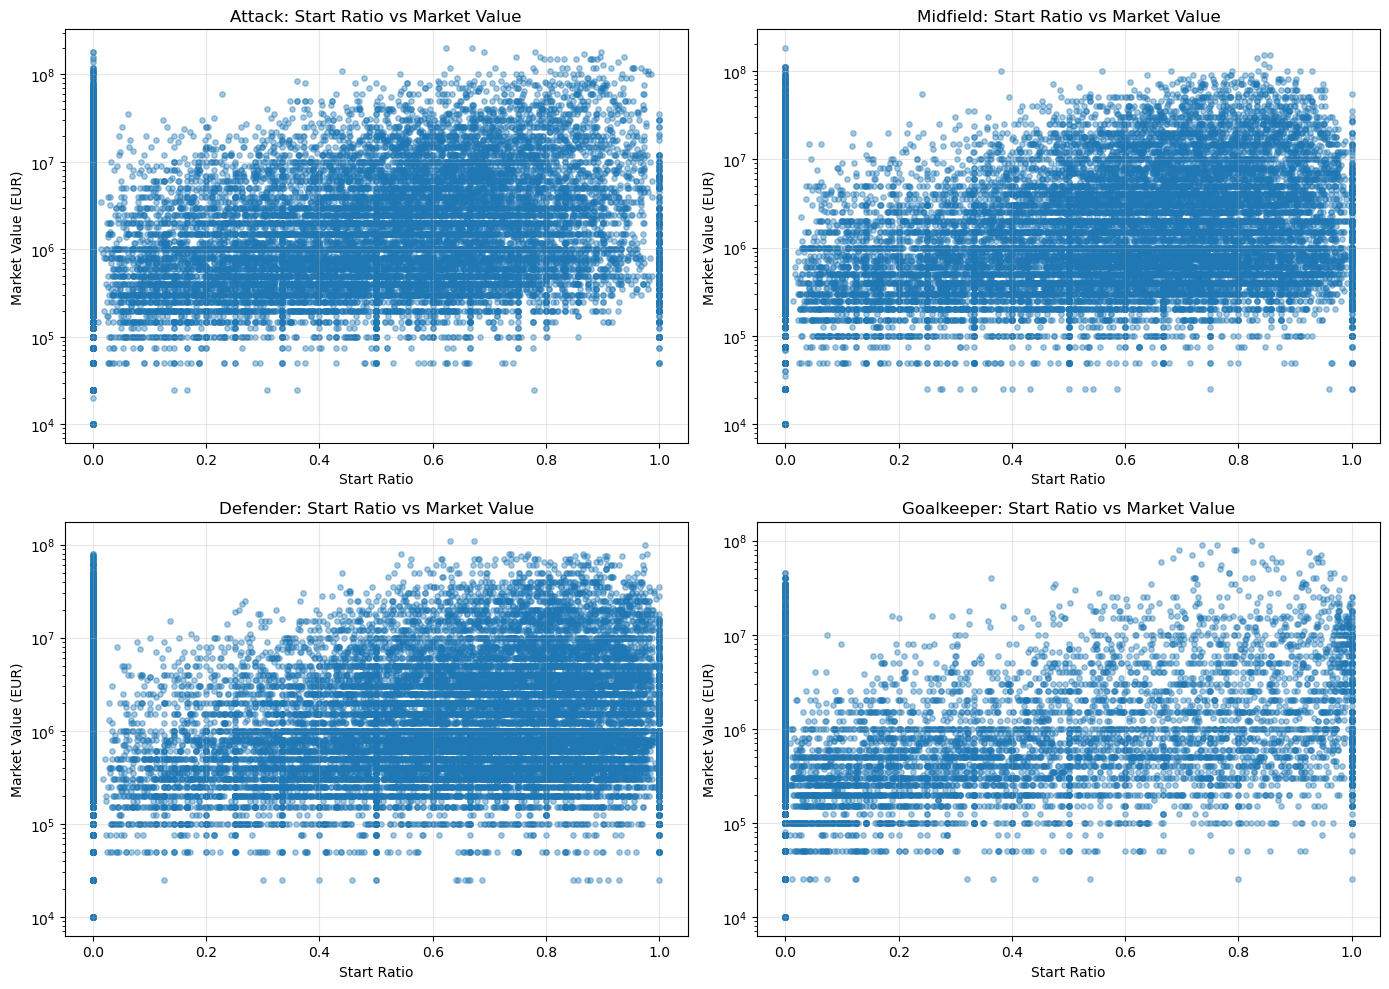

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(["Attack", "Midfield", "Defender", "Goalkeeper"]):
    pos_data = merged_df[merged_df["position"] == pos]

    axes[idx].scatter(
        pos_data["start_ratio"],
        pos_data["market_value_in_eur_valuation"],
        alpha=0.4, s=15
    )
    axes[idx].set_title(f"{pos}: Start Ratio vs Market Value")
    axes[idx].set_xlabel("Start Ratio")
    axes[idx].set_ylabel("Market Value (EUR)")
    axes[idx].set_yscale("log")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


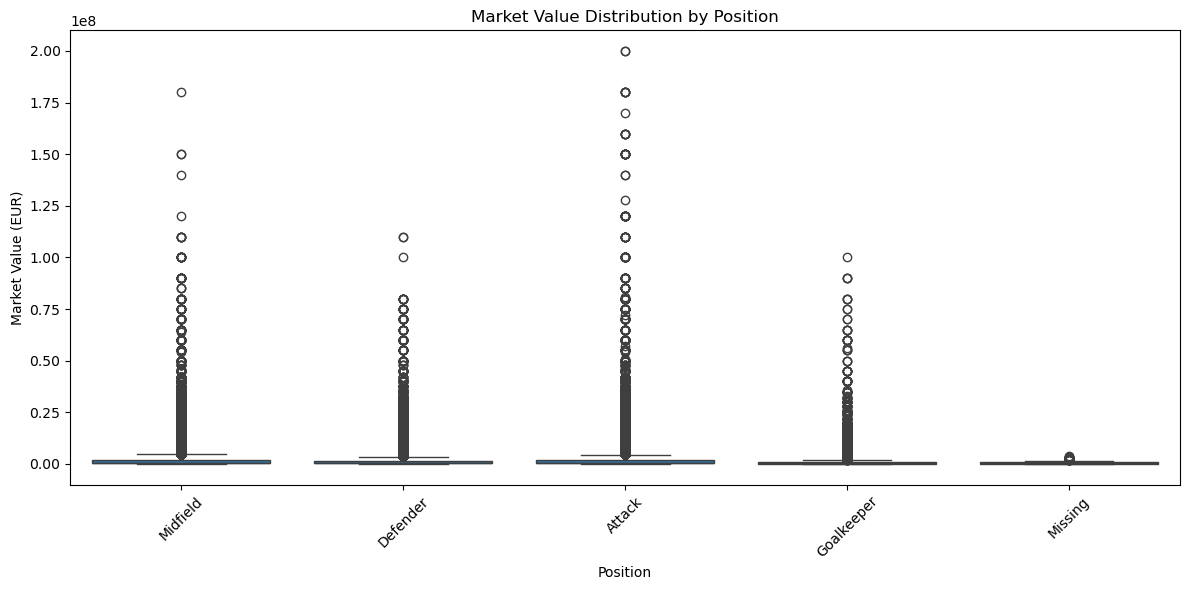

In [75]:
# Boxplot: Market Value by Position, colored by goal-scoring performance
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df, x='position', y='market_value_in_eur_valuation')
plt.xlabel('Position')
plt.ylabel('Market Value (EUR)')
plt.title('Market Value Distribution by Position')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Creating position-specific analysis for Goals...
Note: Filtering to players with >0 goals to show meaningful relationships


/var/folders/_3/vjdmg_yj15j8km8wyn2prr8c0000gn/T/ipykernel_96865/418231510.py:36: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(goals_scaled, value_scaled, 1)


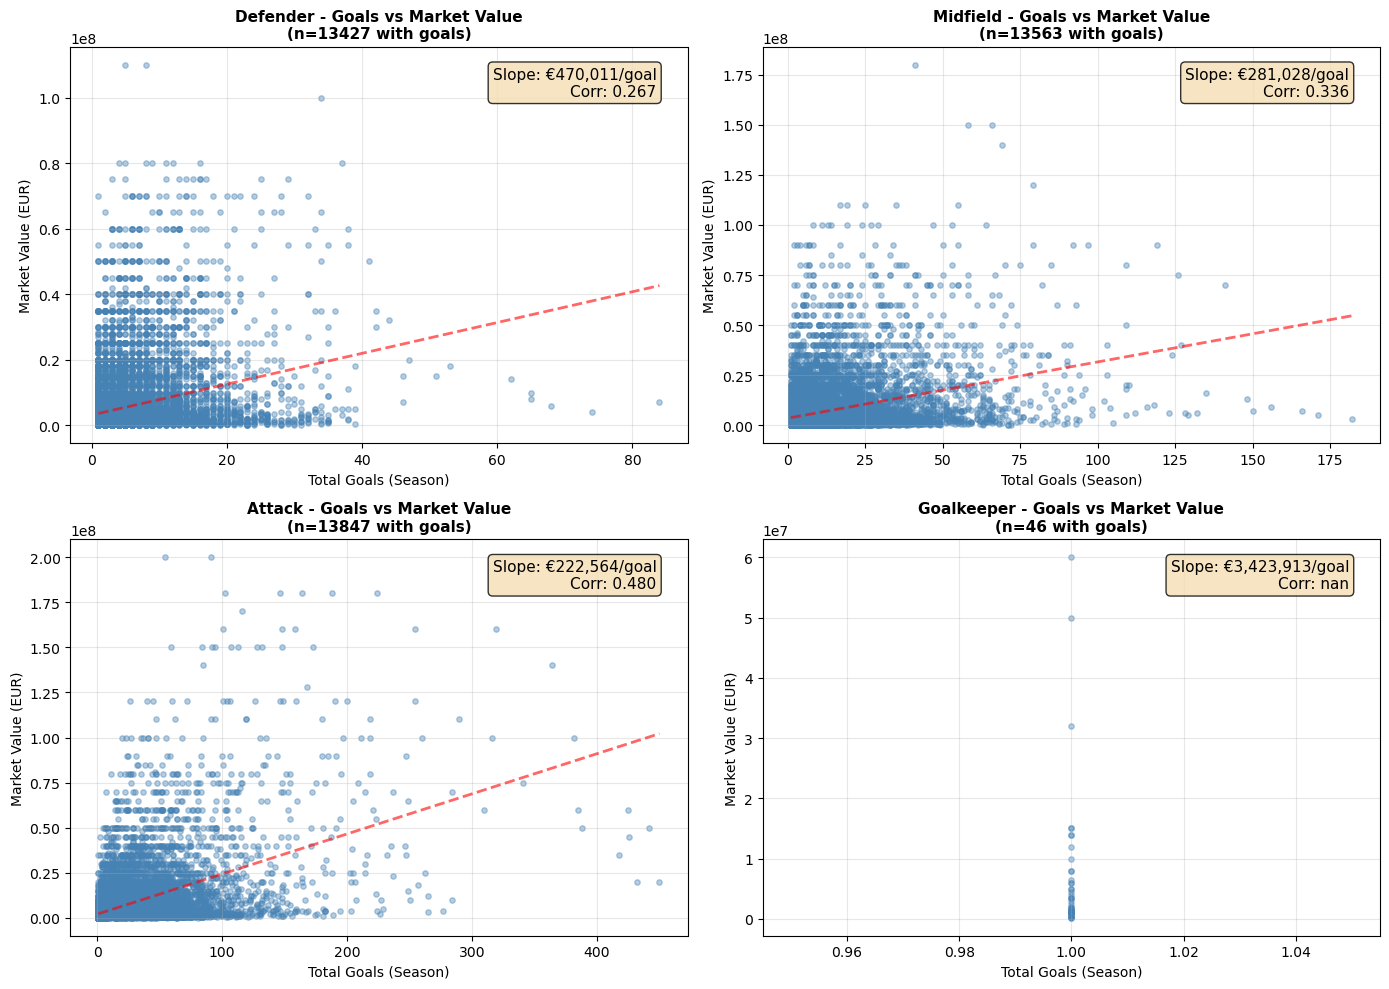


Data coverage after leakage fix:
  Defender: 13427/62278 (21.6%) have goals before valuation
  Midfield: 13563/55371 (24.5%) have goals before valuation
  Attack: 13847/52178 (26.5%) have goals before valuation
  Goalkeeper: 46/21015 (0.2%) have goals before valuation


In [76]:
#Faceted Analysis: Goals by Position (active players)
print("Creating position-specific analysis for Goals...")
print("Note: Filtering to players with >0 goals to show meaningful relationships")

# Get unique positions
positions = merged_df['position'].value_counts().index[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    # Filter players with goals > 0
    pos_data = merged_df[(merged_df['position'] == pos) & (merged_df['total_goals'] > 0)].copy()
    
    axes[idx].scatter(pos_data['total_goals'], 
                      pos_data['market_value_in_eur_valuation'],
                      alpha=0.4, s=15, color='steelblue')
    axes[idx].set_xlabel('Total Goals (Season)', fontsize=10)
    axes[idx].set_ylabel('Market Value (EUR)', fontsize=10)
    axes[idx].set_title(f'{pos} - Goals vs Market Value\n(n={len(pos_data)} with goals)', 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line and calculate statistics
    # Add trend line and calculate statistics
    if len(pos_data) > 10:
        try:
            # Calculate correlation
            correlation = pos_data[['total_goals', 'market_value_in_eur_valuation']].corr().iloc[0, 1]
            
            # Scale data for better numerical stability
            goals_scaled = pos_data['total_goals']
            value_scaled = pos_data['market_value_in_eur_valuation'] / 1e6  # Scale to millions
            
            # Calculate slope (linear regression) on scaled data
            z = np.polyfit(goals_scaled, value_scaled, 1)
            slope_millions = z[0]  # Slope in millions per goal
            slope = slope_millions * 1e6  # Convert back to EUR per goal
            
            p = np.poly1d(z)
            
            # Plot trend line (using scaled values, then convert back)
            x_trend = np.linspace(pos_data['total_goals'].min(), pos_data['total_goals'].max(), 100)
            y_trend_scaled = p(x_trend)
            y_trend = y_trend_scaled * 1e6  # Convert back to EUR
            axes[idx].plot(x_trend, y_trend, "r--", alpha=0.6, linewidth=2)
            
            # Add text box with statistics
            textstr = f'Slope: €{slope:,.0f}/goal\nCorr: {correlation:.3f}'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            axes[idx].text(0.95, 0.95, textstr, transform=axes[idx].transAxes,
                        fontsize=11, verticalalignment='top', horizontalalignment='right',
                        bbox=props)
        except Exception as e:
            print(f"Could not calculate stats for {pos}: {e}")

plt.tight_layout()
plt.show()

# Print summary
print("\nData coverage after leakage fix:")
for pos in positions:
    total = len(merged_df[merged_df['position'] == pos])
    with_goals = len(merged_df[(merged_df['position'] == pos) & (merged_df['total_goals'] > 0)])
    print(f"  {pos}: {with_goals}/{total} ({with_goals/total*100:.1f}%) have goals before valuation")

Creating position-specific analysis for Assists...


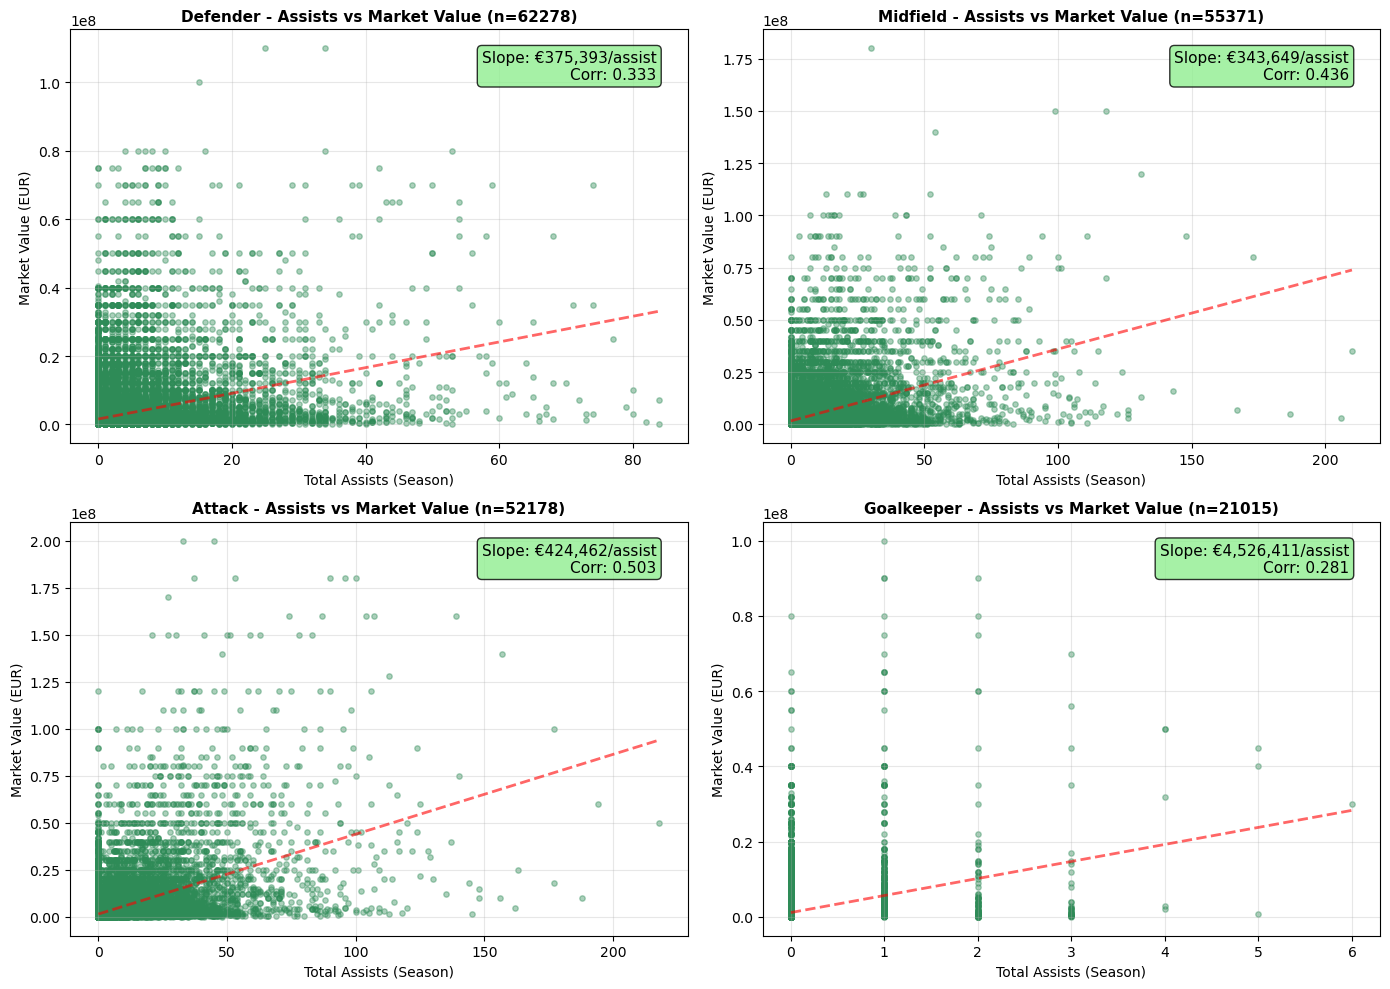

In [77]:
# Faceted Analysis: Assists by Position with Correlation Stats 
print("Creating position-specific analysis for Assists...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    pos_data = merged_df[merged_df['position'] == pos]
    
    axes[idx].scatter(pos_data['total_assists'], 
                      pos_data['market_value_in_eur_valuation'],
                      alpha=0.4, s=15, color='seagreen')
    axes[idx].set_xlabel('Total Assists (Season)', fontsize=10)
    axes[idx].set_ylabel('Market Value (EUR)', fontsize=10)
    axes[idx].set_title(f'{pos} - Assists vs Market Value (n={len(pos_data)})', 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line and calculate statistics
    if len(pos_data) > 10:
        # Calculate correlation
        correlation = pos_data[['total_assists', 'market_value_in_eur_valuation']].corr().iloc[0, 1]
        
        # Calculate slope (linear regression)
        z = np.polyfit(pos_data['total_assists'], pos_data['market_value_in_eur_valuation'], 1)
        slope = z[0]
        p = np.poly1d(z)
        
        # Plot trend line
        x_trend = np.linspace(pos_data['total_assists'].min(), pos_data['total_assists'].max(), 100)
        axes[idx].plot(x_trend, p(x_trend), "r--", alpha=0.6, linewidth=2)
        
        # Add text box with statistics in top right
        textstr = f'Slope: €{slope:,.0f}/assist\nCorr: {correlation:.3f}'
        props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
        axes[idx].text(0.95, 0.95, textstr, transform=axes[idx].transAxes, 
                      fontsize=11, verticalalignment='top', horizontalalignment='right',
                      bbox=props)

plt.tight_layout()
plt.show()

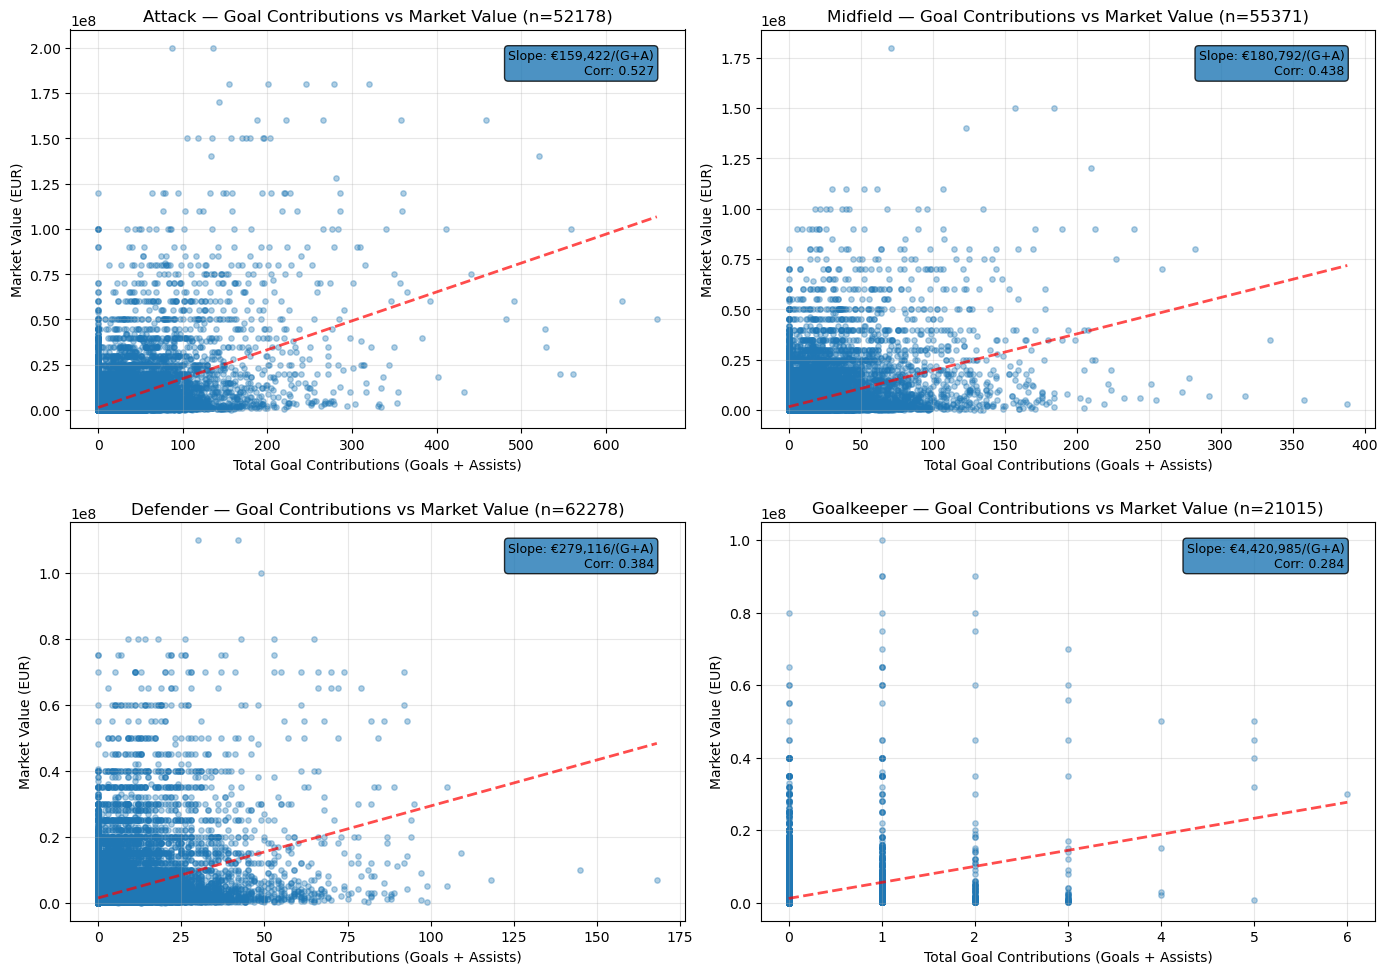

In [78]:
# Goal contributions = goals + assists (season totals)
merged_df["total_goal_contributions"] = merged_df["total_goals"] + merged_df["total_assists"]

# Look at per-90 since minutes are very uneven (already made goal_contributions_per_90 in perf_stats, this just ensures it exists in merged_df)

positions = ["Attack", "Midfield", "Defender", "Goalkeeper"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    pos_data = merged_df[merged_df["position"] == pos].copy()

    # helpful: drop missing/inf just for plotting
    pos_data = pos_data.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["total_goal_contributions", "market_value_in_eur_valuation"]
    )

    axes[idx].scatter(
        pos_data["total_goal_contributions"],
        pos_data["market_value_in_eur_valuation"],
        alpha=0.35, s=15
    )
    axes[idx].set_xlabel("Total Goal Contributions (Goals + Assists)")
    axes[idx].set_ylabel("Market Value (EUR)")
    axes[idx].set_title(f"{pos} — Goal Contributions vs Market Value (n={len(pos_data)})")
    axes[idx].grid(True, alpha=0.3)

    if len(pos_data) > 10:
        corr = pos_data[["total_goal_contributions", "market_value_in_eur_valuation"]].corr().iloc[0, 1]
        z = np.polyfit(pos_data["total_goal_contributions"], pos_data["market_value_in_eur_valuation"], 1)
        slope = z[0]
        p = np.poly1d(z)

        x_trend = np.linspace(pos_data["total_goal_contributions"].min(),
                              pos_data["total_goal_contributions"].max(), 100)
        axes[idx].plot(x_trend, p(x_trend), "r--", alpha=0.7, linewidth=2)

        axes[idx].text(
            0.95, 0.95,
            f"Slope: €{slope:,.0f}/(G+A)\nCorr: {corr:.3f}",
            transform=axes[idx].transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.8)
        )

plt.tight_layout()
plt.show()


count    191153.000000
mean         13.442384
std           1.494572
min           9.210440
25%          12.429220
50%          13.304687
75%          14.403298
max          19.113828
Name: market_value_next_year, dtype: float64

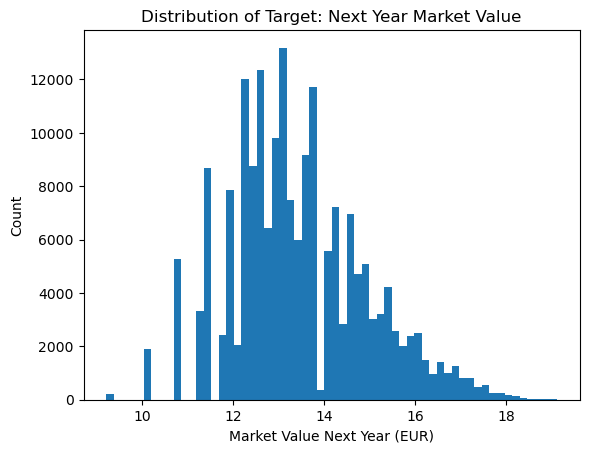

In [79]:
# Statistics

display(y.describe())

plt.figure()
plt.hist(y, bins=60)
plt.xlabel("Market Value Next Year (EUR)")
plt.ylabel("Count")
plt.title("Distribution of Target: Next Year Market Value")
plt.show()


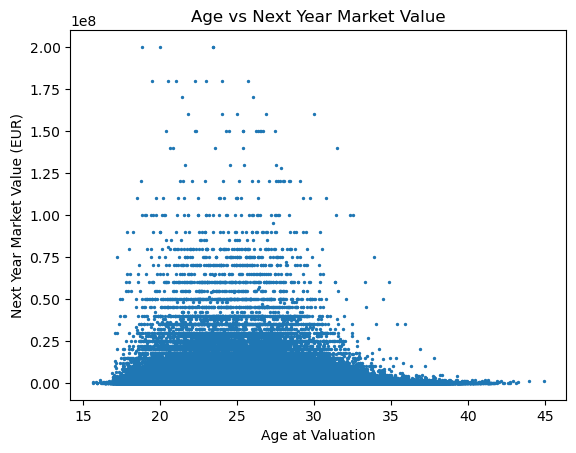

In [80]:
# age vs next-year value

plt.figure()
plt.scatter(merged_df["age_at_valuation"], merged_df["market_value_next_year"], s=2)
plt.xlabel("Age at Valuation")
plt.ylabel("Next Year Market Value (EUR)")
plt.title("Age vs Next Year Market Value")
plt.show()


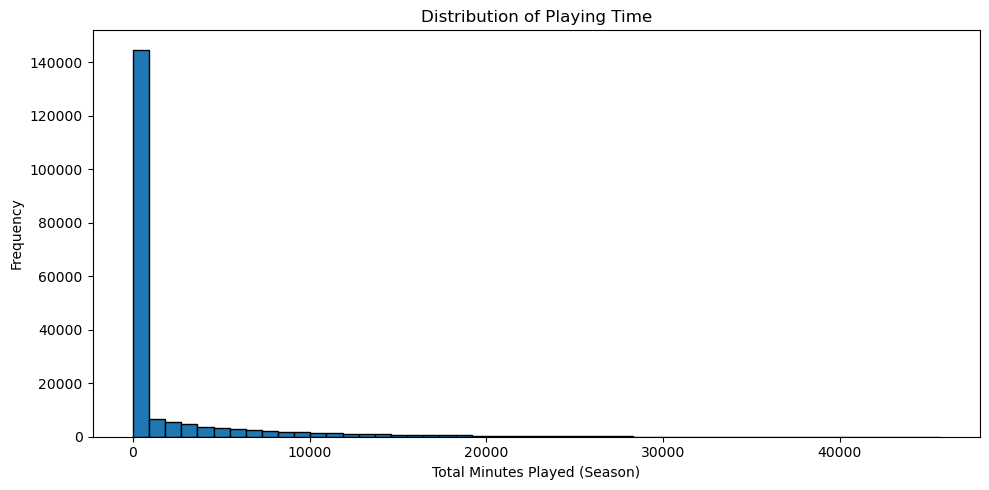

In [81]:
# Minutes Played Distribution
plt.figure(figsize=(10, 5))
plt.hist(merged_df['total_minutes'], bins=50, edgecolor='black')
plt.xlabel('Total Minutes Played (Season)')
plt.ylabel('Frequency')
plt.title('Distribution of Playing Time')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

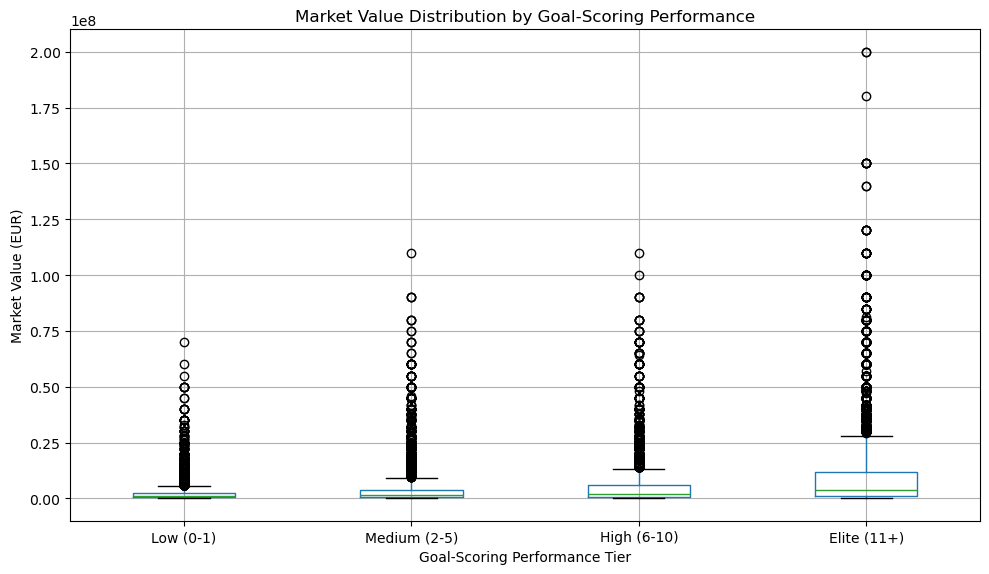

In [82]:
# Market Value by Performance Tier (boxplot)
# Create performance tiers
merged_df['performance_tier'] = pd.cut(
    merged_df['total_goals'], 
    bins=[0, 1, 5, 10, 100], 
    labels=['Low (0-1)', 'Medium (2-5)', 'High (6-10)', 'Elite (11+)']
)

plt.figure(figsize=(10, 6))
merged_df.boxplot(column='market_value_in_eur_valuation', by='performance_tier', 
                  figsize=(10, 6))
plt.xlabel('Goal-Scoring Performance Tier')
plt.ylabel('Market Value (EUR)')
plt.title('Market Value Distribution by Goal-Scoring Performance')
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

NORMALITY ASSESSMENT (Q-Q PLOTS)


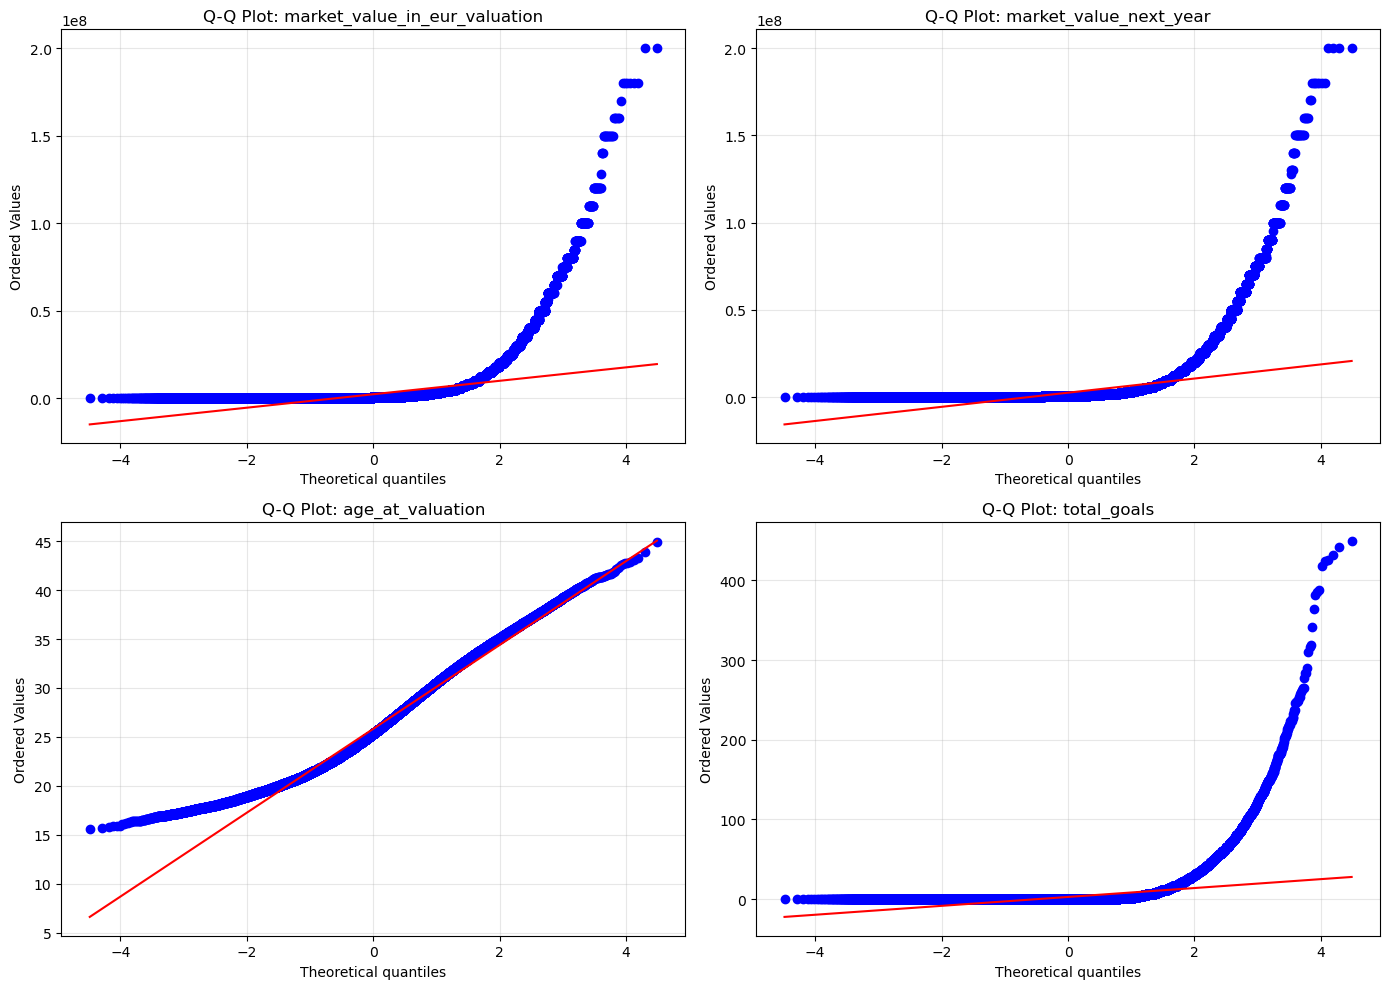


Variables deviating from normal distribution may benefit from transformation


In [83]:
# Q-Q Plots for Normality Assessment

print("="*60)
print("NORMALITY ASSESSMENT (Q-Q PLOTS)")
print("="*60)

key_vars_qq = ['market_value_in_eur_valuation', 'market_value_next_year',
               'age_at_valuation', 'total_goals']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(key_vars_qq):
    data = merged_df[var].replace([np.inf, -np.inf], np.nan).dropna()
    stats.probplot(data, dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q Plot: {var}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVariables deviating from normal distribution may benefit from transformation")

MARKET VALUE TRENDS OVER TIME


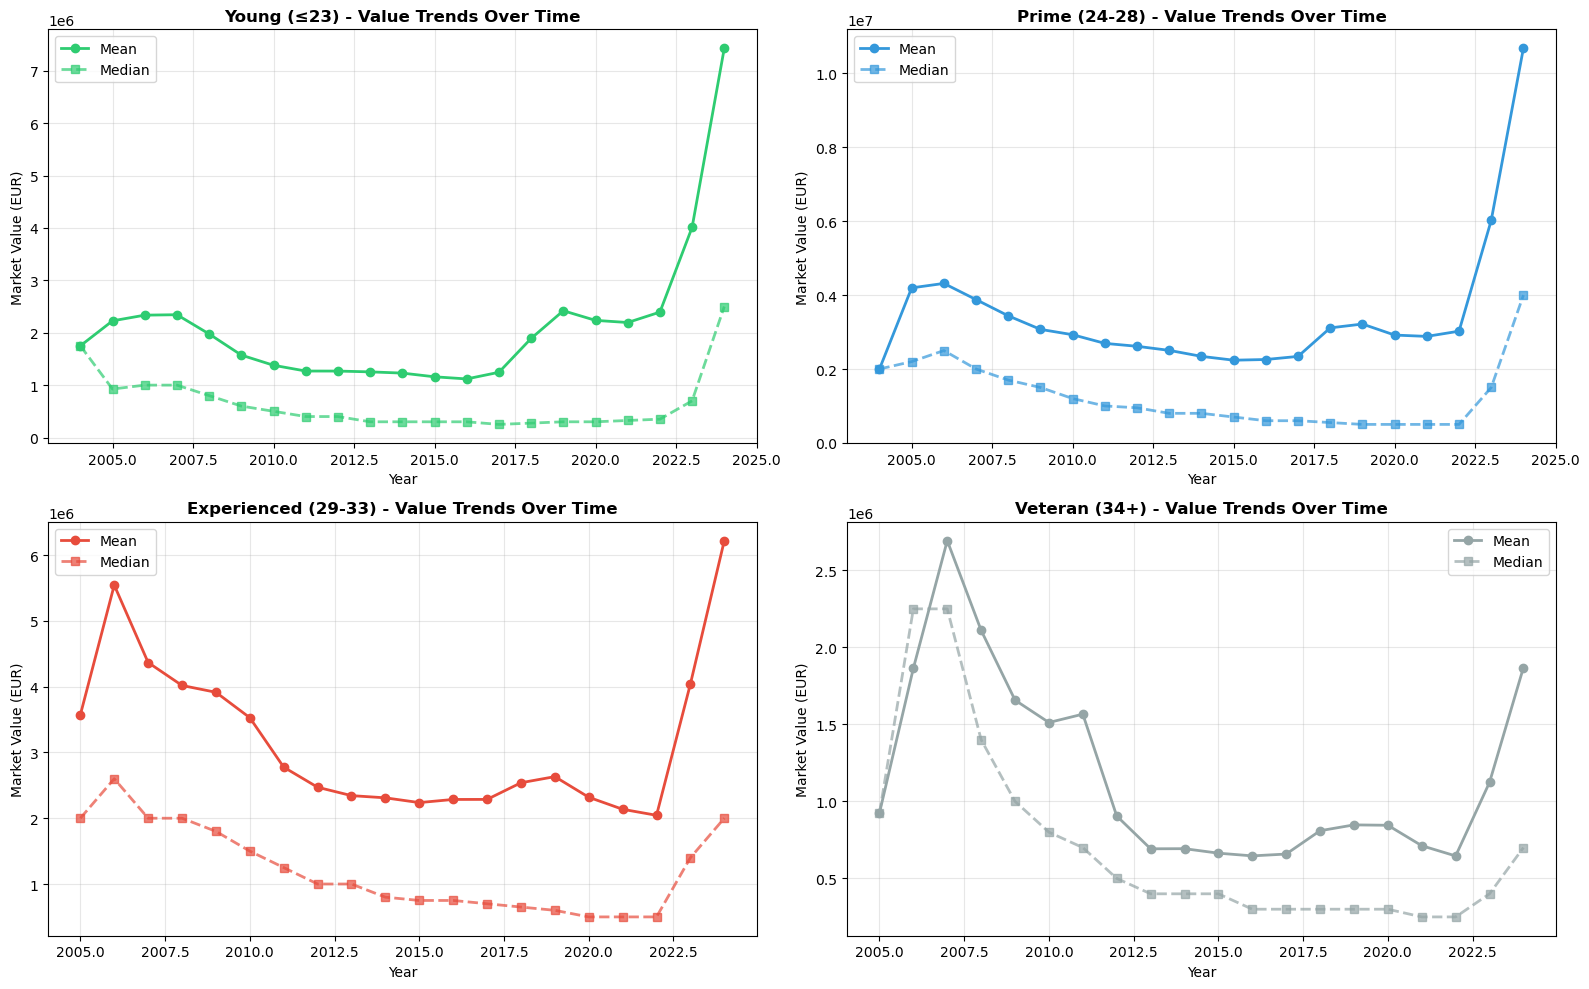

In [84]:
# Market Value Trends Over Time by Age Group
print("="*60)
print("MARKET VALUE TRENDS OVER TIME")
print("="*60)

yearly_trends = merged_df.groupby(['year', 'age_group'], observed=True)['market_value_in_eur_valuation'].agg(['mean', 'median']).reset_index()

age_groups = ['Young (≤23)', 'Prime (24-28)', 'Experienced (29-33)', 'Veteran (34+)']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, age_group in enumerate(age_groups):
    data = yearly_trends[yearly_trends['age_group'] == age_group]
    axes[idx].plot(data['year'], data['mean'], marker='o', linewidth=2, label='Mean', color=colors[idx])
    axes[idx].plot(data['year'], data['median'], marker='s', linewidth=2, linestyle='--', label='Median', alpha=0.7, color=colors[idx])
    axes[idx].set_xlabel('Year')
    axes[idx].set_ylabel('Market Value (EUR)')
    axes[idx].set_title(f'{age_group} - Value Trends Over Time', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

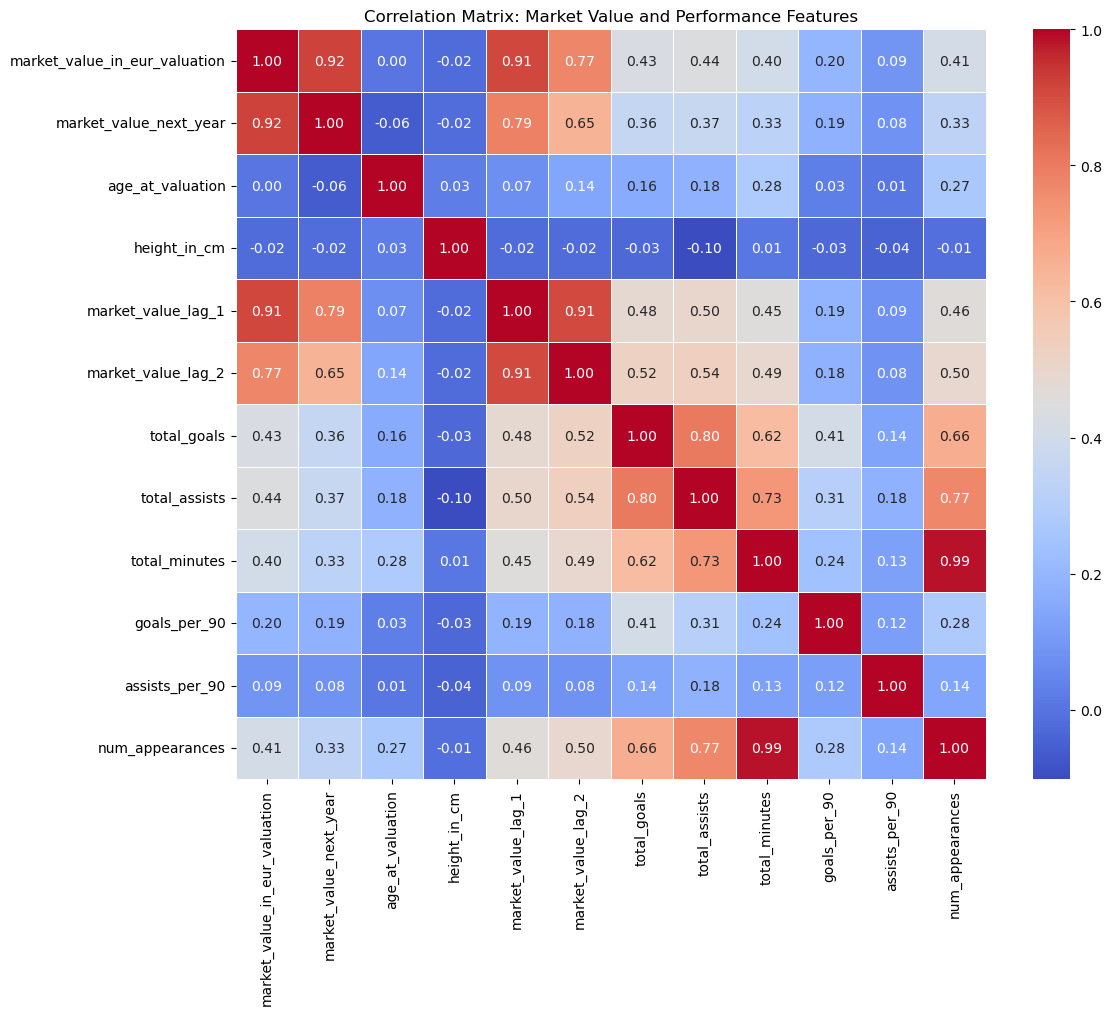

In [85]:
# Correlation heatmap 
import seaborn as sns

# Select key features including performance stats
corr_features = ['market_value_in_eur_valuation', 'market_value_next_year',
                 'age_at_valuation', 'height_in_cm',
                 'market_value_lag_1', 'market_value_lag_2',
                 'total_goals', 'total_assists', 'total_minutes',
                 'goals_per_90', 'assists_per_90', 'num_appearances']

corr_matrix = merged_df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Market Value and Performance Features')
plt.tight_layout()
plt.show()


## 4. Data Analytics (Modeling)
This is a **supervised learning regression** problem. We compare multiple algorithms and evaluate them using MAE, RMSE, and R². We also do time-aware train/test splitting to reduce leakage risk.

In [86]:
# Train/Test split (time-aware)
# We preserve order (shuffle=False) because data is time-dependent.

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# print("Train:", X_train.shape, y_train.shape)
# print("Test:", X_test.shape, y_test.shape)

# Train/Test split (time-aware)
print("="*60)
print("TIME-BASED TRAIN/TEST SPLIT")
print("="*60)

# Use date from merged_encoded to create time-based split
cutoff_date = merged_encoded['date'].quantile(0.8)
print(f"Cutoff date: {cutoff_date}")

# Create masks
train_mask = merged_encoded['date'] < cutoff_date
test_mask = merged_encoded['date'] >= cutoff_date

# Apply masks
X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print(f"Train date range: {merged_encoded.loc[train_mask, 'date'].min()} to {merged_encoded.loc[train_mask, 'date'].max()}")
print(f"Test date range: {merged_encoded.loc[test_mask, 'date'].min()} to {merged_encoded.loc[test_mask, 'date'].max()}")


TIME-BASED TRAIN/TEST SPLIT
Cutoff date: 2021-11-30 00:00:00
Train: (152899, 66) (152899,)
Test: (38254, 66) (38254,)
Train date range: 2004-10-04 00:00:00 to 2021-11-25 00:00:00
Test date range: 2021-11-30 00:00:00 to 2024-12-30 00:00:00


We compare:
- Linear Regression (baseline)
- ElasticNet (regularized linear)
- Random Forest (non-linear)
- KNN (distance-based)

For KNN and ElasticNet we benefit from scaling, so we use pipelines.

In [87]:
# Models + evaluation

# def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
#     """
#     Train model, evaluate on test set, and perform cross-validation
#     """
#     # Train the model
#     model.fit(X_tr, y_tr)
    
#     # Test set predictions
#     pred = model.predict(X_te)
    
#     # Cross-validation on training set (5-fold)
#     print(f"\n{'='*60}")
#     print(f"Cross-Validation: {name}")
#     print(f"{'='*60}")
    
#     cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
#     cv_mae = -cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
#     cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
    
#     print(f"  R² scores:   {cv_r2}")
#     print(f"  Mean R²:     {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
#     print(f"  MAE scores:  {cv_mae}")
#     print(f"  Mean MAE:    €{cv_mae.mean():,.2f} (+/- €{cv_mae.std():,.2f})")
#     print(f"  RMSE scores: {cv_rmse}")
#     print(f"  Mean RMSE:   €{cv_rmse.mean():,.2f} (+/- €{cv_rmse.std():,.2f})")
    
#     return {
#         "Model": name,
#         "MAE": mean_absolute_error(y_te, pred),
#         "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
#         "R2": r2_score(y_te, pred),
#         "CV_R2_Mean": cv_r2.mean(),
#         "CV_R2_Std": cv_r2.std(),
#         "CV_MAE_Mean": cv_mae.mean(),
#         "CV_RMSE_Mean": cv_rmse.mean()
#     }

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train model and evaluate on test set
    """
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Test set predictions
    pred = model.predict(X_te)
    
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "R2": r2_score(y_te, pred)
    }

models = []

# Baselines (no scaling needed)
models.append(("Linear Regression", LinearRegression()))
models.append(("Random Forest", RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)))

# Pipelines (imputer + scaler) helps for KNN/ElasticNet
elastic_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42))
])

knn_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=10))
])

models.append(("ElasticNet (scaled)", elastic_pipe))
models.append(("KNN (scaled)", knn_pipe))

results = []
for name, model in models:
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,Model,MAE,RMSE,R2
1,Random Forest,0.549416,0.732791,0.802636
3,KNN (scaled),0.795325,1.028364,0.611312
0,Linear Regression,0.908244,1.206315,0.465154
2,ElasticNet (scaled),0.952564,1.226933,0.446715


We use `TimeSeriesSplit` to evaluate models with time-aware cross-validation. This avoids mixing future information into training folds.

### TimeSeriesSplit Cross-Validation for Temporal Integrity

**Why TimeSeriesSplit?** Standard K-Fold randomly splits data, causing temporal leakage (future data in training folds). TimeSeriesSplit respects time order: each fold only uses past data to predict future data.

**Implementation:** Data is sorted by date, creating expanding training windows (e.g., Train: 2000-2015 → Test: 2016, Train: 2000-2016 → Test: 2017).

In [88]:
# TimeSeries cross-validation (on a subset for speed)

# tscv = TimeSeriesSplit(n_splits=5)

# # For speed, sample a subset
# sample_size = min(120000, len(X_train))
# X_cv = X_train.iloc[:sample_size]
# y_cv = y_train.iloc[:sample_size]

# # Use MAE (negative in sklearn scoring conventions)
# def cv_mae(model):
#     scores = cross_val_score(
#         model, X_cv, y_cv,
#         cv=tscv,
#         scoring="neg_mean_absolute_error",
#         n_jobs=-1
#     )
#     return -scores.mean(), scores.std()

# cv_rows = []
# for name, model in models:
#     mean_mae, std_mae = cv_mae(model)
#     cv_rows.append({"Model": name, "CV_MAE_mean": mean_mae, "CV_MAE_std": std_mae})

# cv_df = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean")
# cv_df

# TimeSeries cross-validation

print("\n" + "="*60)
print("TIME-SERIES CROSS-VALIDATION")
print("="*60)

# Ensure data is sorted by date
sort_idx = merged_encoded['date'].sort_values().index
X_sorted = X.loc[sort_idx].copy()
y_sorted = y.loc[sort_idx].copy()

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

cv_rows = []
for name, model in models:
    print(f"\nEvaluating {name}...")
    scores = cross_val_score(
        model, X_sorted, y_sorted,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    mean_mae = -scores.mean()
    std_mae = scores.std()
    cv_rows.append({"Model": name, "CV_MAE_mean": mean_mae, "CV_MAE_std": std_mae})
    print(f"  MAE: €{mean_mae:,.2f} (+/- €{std_mae:,.2f})")

cv_df = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean")
print("\n" + "="*60)
print("TimeSeriesSplit Results:")
print("="*60)
display(cv_df)


TIME-SERIES CROSS-VALIDATION

Evaluating Linear Regression...
  MAE: €0.91 (+/- €0.01)

Evaluating Random Forest...
  MAE: €0.59 (+/- €0.03)

Evaluating ElasticNet (scaled)...


/opt/anaconda3/envs/final_project_data_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  MAE: €0.95 (+/- €0.01)

Evaluating KNN (scaled)...
  MAE: €0.83 (+/- €0.03)

TimeSeriesSplit Results:


,Model,CV_MAE_mean,CV_MAE_std
1,Random Forest,0.586587,0.028868
3,KNN (scaled),0.825976,0.030137
0,Linear Regression,0.914603,0.010876
2,ElasticNet (scaled),0.952133,0.013865


In [89]:
# Hyperparameter Tuning

print("\n" + "="*60)
print("HYPERPARAMETER TUNING (Random Forest)")
print("="*60)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [15, 18, 20],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_model, 
    param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest (this may take a few minutes)...")
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV MAE: €{-rf_grid.best_score_:,.2f}")

# Update models list
models[1] = ("Random Forest (Tuned)", rf_grid.best_estimator_)
print("Random Forest updated with best parameters")


HYPERPARAMETER TUNING (Random Forest)
Tuning Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/opt/anaconda3/envs/final_project_data_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: €0.60
Random Forest updated with best parameters


We inspect which features contribute most to predictions (interpretability).

market_value_lag_1                       0.693556
age_at_valuation                         0.101033
current_club_id_valuation                0.024125
market_value_lag_2                       0.020959
market_value_mean_3                      0.020899
minutes_trend                            0.019157
height_in_cm                             0.013109
market_value_trend                       0.009084
domestic_competition_id_valuation_GB1    0.006589
age_attack_interaction                   0.005549
start_ratio                              0.005175
minutes_lag_1                            0.005143
age_midfielder_interaction               0.004893
height_defender_interaction              0.004387
domestic_competition_id_valuation_IT1    0.004291
dtype: float64

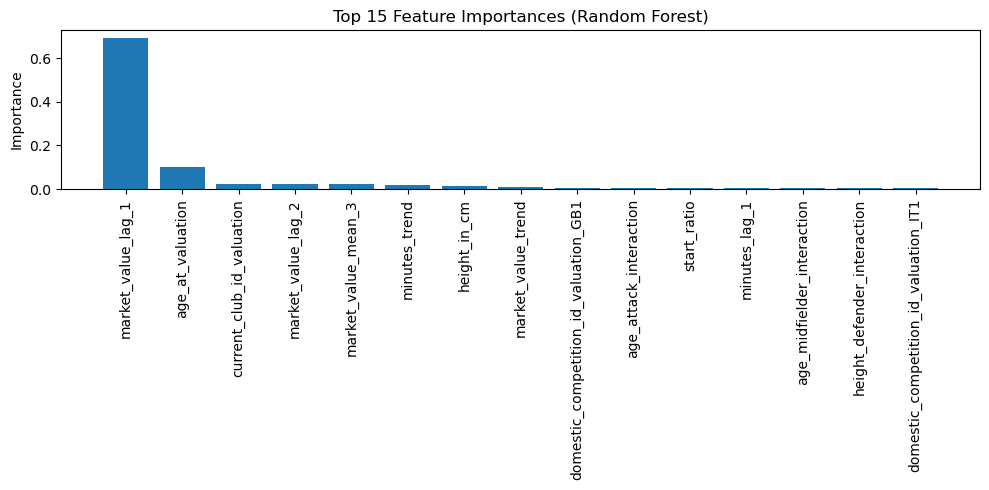

In [90]:
# Feature importance (Random Forest)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Compute importances
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_k = 15
display(importances.head(top_k))

# Plot feature importances
top_feats = importances.head(top_k)

x = np.arange(len(top_feats))
y = top_feats.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.xticks(x, top_feats.index, rotation=90)
plt.ylabel("Importance")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [91]:
# Analyze top performing features 
print("=" * 60)
print("Top 20 Feature Importances (Random Forest)")
print("=" * 60)

# Get feature importances from your trained RF model
rf = RandomForestRegressor(n_estimators=150, max_depth=18, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\nTop 20 Features:")
display(importances.head(20))

# Highlight performance features
print("\n Performance-Related Features in Top 20:")
perf_feature_keywords = ['goal', 'assist', 'minutes', 'appearance', 'cards']
top_20_features = importances.head(20)
for feat in top_20_features.index:
    if any(keyword in feat.lower() for keyword in perf_feature_keywords):
        print(f"  - {feat}: {top_20_features[feat]:.4f}")

Top 20 Feature Importances (Random Forest)

Top 20 Features:


market_value_lag_1                       0.693556
age_at_valuation                         0.101033
current_club_id_valuation                0.024125
market_value_lag_2                       0.020959
market_value_mean_3                      0.020899
minutes_trend                            0.019157
height_in_cm                             0.013109
market_value_trend                       0.009084
domestic_competition_id_valuation_GB1    0.006589
age_attack_interaction                   0.005549
start_ratio                              0.005175
minutes_lag_1                            0.005143
age_midfielder_interaction               0.004893
height_defender_interaction              0.004387
domestic_competition_id_valuation_IT1    0.004291
lineup_matches                           0.003698
domestic_competition_id_valuation_ES1    0.003196
domestic_competition_id_valuation_TR1    0.003160
cards_per_90                             0.002903
age_goals_trend                          0.002836



 Performance-Related Features in Top 20:
  - minutes_trend: 0.0192
  - minutes_lag_1: 0.0051
  - cards_per_90: 0.0029
  - age_goals_trend: 0.0028


A quick diagnostic plot to visually assess model fit.

PREDICTIONS VS ACTUAL VALUES
Best model: Random Forest
Valid predictions: 38254 / 38254 (100.0%)


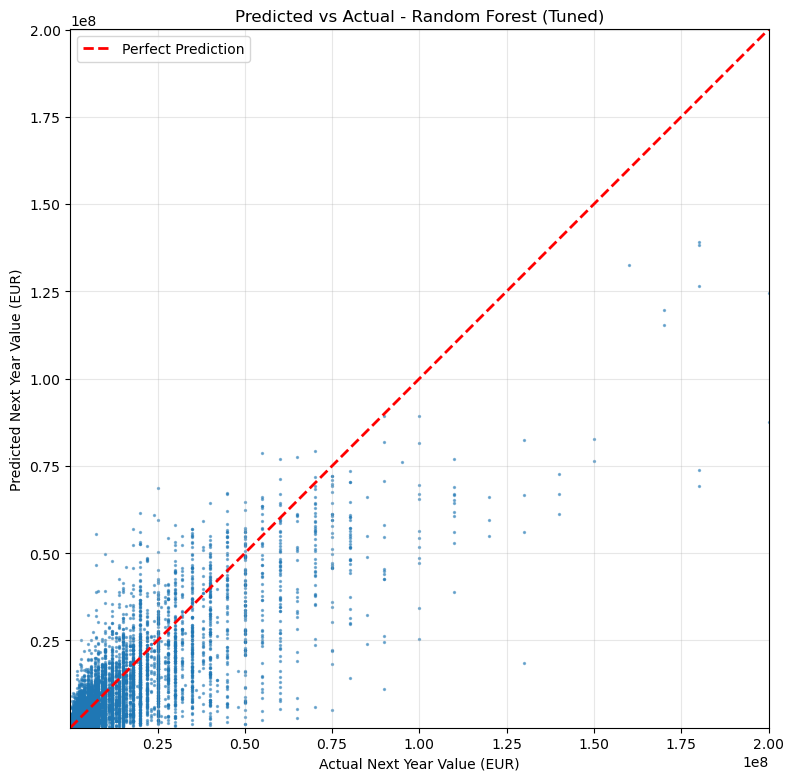

In [92]:
# Predicted vs actual
print("="*60)
print("PREDICTIONS VS ACTUAL VALUES")
print("="*60)

# Get the best model from results_df
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

# Find the model - handle both tuned and non-tuned names
model_dict = dict(models)
if best_model_name in model_dict:
    best_model = model_dict[best_model_name]
elif best_model_name == "Random Forest" and "Random Forest (Tuned)" in model_dict:
    best_model = model_dict["Random Forest (Tuned)"]
    best_model_name = "Random Forest (Tuned)"
else:
    # If still not found, use the first model in the list
    best_model = models[0][1]
    best_model_name = models[0][0]
    print(f"Model not found, using: {best_model_name}")

# Train and predict
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

# Inverse transform predictions with overflow protection
pred_clipped = np.clip(pred, -10, 20)  # Reasonable range in log space
pred = np.expm1(pred_clipped)
y_test_original = np.expm1(y_test)

# Remove any remaining invalid values
valid_mask = np.isfinite(pred) & np.isfinite(y_test_original)
pred = pred[valid_mask]
y_test_original = y_test_original[valid_mask]

print(f"Valid predictions: {len(pred)} / {len(y_test)} ({len(pred)/len(y_test)*100:.1f}%)")

# Plot
min_val = min(y_test_original.min(), pred.min())
max_val = max(y_test_original.max(), pred.max())

plt.figure(figsize=(8, 8))
plt.scatter(y_test_original, pred, s=2, alpha=0.5)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect("equal", adjustable="box")
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Next Year Value (EUR)")
plt.ylabel("Predicted Next Year Value (EUR)")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


PREDICTED VS ACTUAL - DENSITY VISUALIZATION
Valid predictions: 38254 / 38254 (100.0%)


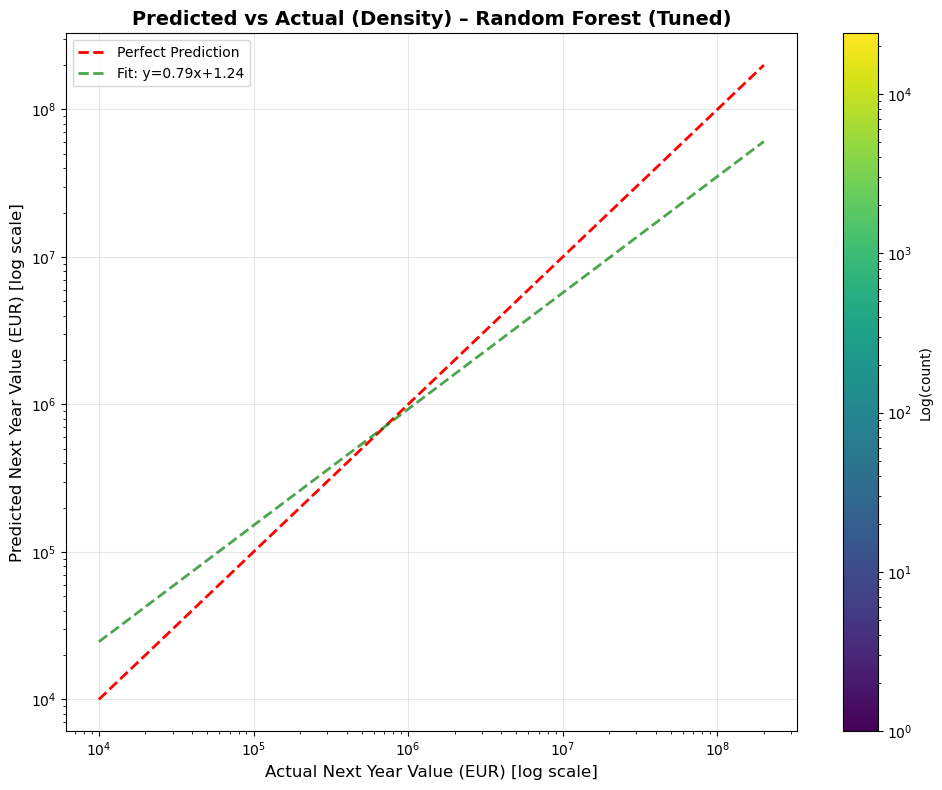


Test Set Performance (cleaned data):
  MAE: €1,557,064.09
  RMSE: €4,851,775.28
  R²: 0.7335


In [93]:

# Predicted vs Actual 

# Predicted vs Actual (Hexbin Density Plot)
print("="*60)
print("PREDICTED VS ACTUAL - DENSITY VISUALIZATION")
print("="*60)

# Use the tuned Random Forest model
final_model = models[1][1]  # Random Forest (Tuned)
final_model_name = models[1][0]

final_model.fit(X_train, y_train)
pred = final_model.predict(X_test)

# Inverse transform with overflow protection
# Clip predictions before inverse transform to prevent overflow
pred_clipped = np.clip(pred, -10, 20)  # Reasonable range in log space
pred = np.expm1(pred_clipped)
y_test_original = np.expm1(y_test)

# Convert to numpy arrays
y_true = np.asarray(y_test_original).astype(float)
y_pred = np.asarray(pred).astype(float)

# Remove invalid values (NaN, Inf, non-positive)
mask = (
    (y_true > 0) & 
    (y_pred > 0) & 
    np.isfinite(y_true) & 
    np.isfinite(y_pred) &
    (y_true < 1e9) &  # Remove extreme outliers
    (y_pred < 1e9)
)

y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]

print(f"Valid predictions: {len(y_true_clean)} / {len(y_true)} ({len(y_true_clean)/len(y_true)*100:.1f}%)")

# Hexbin density plot
plt.figure(figsize=(10, 8))
hb = plt.hexbin(y_true_clean, y_pred_clean, gridsize=60, bins='log', mincnt=1)
plt.colorbar(hb, label="Log(count)")

# Log scales
plt.xscale("log")
plt.yscale("log")

# 45-degree line (perfect predictions)
min_v = min(y_true_clean.min(), y_pred_clean.min())
max_v = max(y_true_clean.max(), y_pred_clean.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction')

# Fit line to show overall calibration
logx = np.log10(y_true_clean)
logy = np.log10(y_pred_clean)
m, b = np.polyfit(logx, logy, 1)
x_line = np.logspace(np.log10(min_v), np.log10(max_v), 200)
y_line = 10**(m*np.log10(x_line) + b)
plt.plot(x_line, y_line, 'g--', linewidth=2, alpha=0.7, label=f'Fit: y={m:.2f}x+{b:.2f}')

plt.xlabel("Actual Next Year Value (EUR) [log scale]", fontsize=12)
plt.ylabel("Predicted Next Year Value (EUR) [log scale]", fontsize=12)
plt.title(f"Predicted vs Actual (Density) – {final_model_name}", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
mae_clean = mean_absolute_error(y_true_clean, y_pred_clean)
rmse_clean = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
r2_clean = r2_score(y_true_clean, y_pred_clean)

print(f"\nTest Set Performance (cleaned data):")
print(f"  MAE: €{mae_clean:,.2f}")
print(f"  RMSE: €{rmse_clean:,.2f}")
print(f"  R²: {r2_clean:.4f}")

DETAILED PREDICTION ANALYSIS


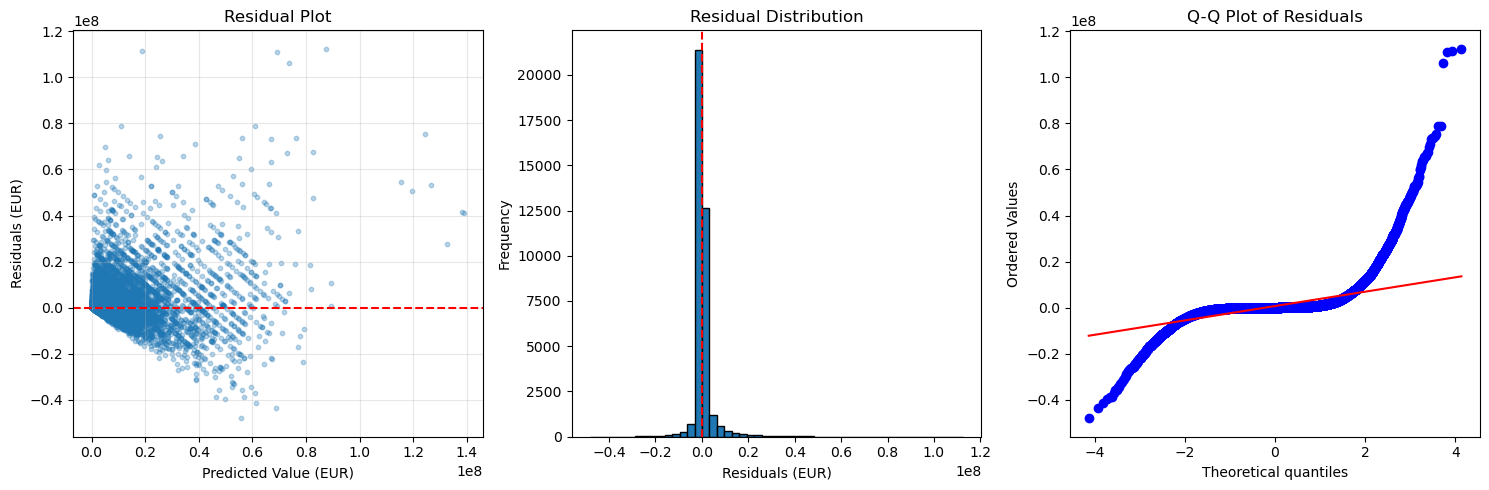


Mean Absolute Error by Value Tier:


,mean,std,count
Tier,,,
Low (<1M),1.998089e+05,3.300985e+05,24897
Medium (1-5M),1.362597e+06,1.480395e+06,8237
High (5-20M),5.038810e+06,4.302427e+06,3375
Elite (>20M),1.510578e+07,1.348442e+07,1745



Percentage Error Statistics:
  Mean: -28.98%
  Median: -1.40%
  Within ±20%: 25.7%
  Within ±50%: 59.3%


In [94]:
# Enhanced Prediction Analysis
print("="*60)
print("DETAILED PREDICTION ANALYSIS")
print("="*60)

residuals = y_test_original - pred

# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(pred, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Value (EUR)')
axes[0].set_ylabel('Residuals (EUR)')
axes[0].set_title('Residual Plot')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residuals (EUR)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].axvline(x=0, color='r', linestyle='--')

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# Error by value tier
test_value_tiers = pd.cut(
    y_test_original,
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

error_by_tier = pd.DataFrame({
    'Absolute_Error': np.abs(residuals),
    'Tier': test_value_tiers
})

print("\nMean Absolute Error by Value Tier:")
display(error_by_tier.groupby('Tier', observed=True)['Absolute_Error'].agg(['mean', 'std', 'count']))

# Percentage error
pct_error = (residuals / y_test_original) * 100
print(f"\nPercentage Error Statistics:")
print(f"  Mean: {pct_error.mean():.2f}%")
print(f"  Median: {pct_error.median():.2f}%")
print(f"  Within ±20%: {(np.abs(pct_error) <= 20).sum() / len(pct_error) * 100:.1f}%")
print(f"  Within ±50%: {(np.abs(pct_error) <= 50).sum() / len(pct_error) * 100:.1f}%")

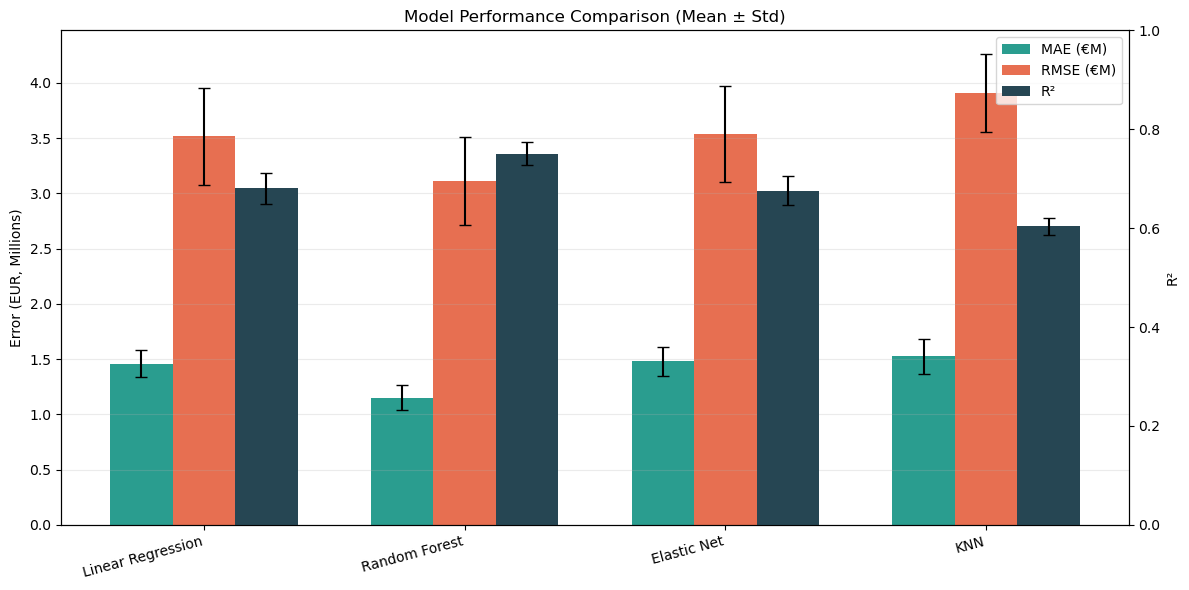

In [95]:
# note: Results below reflect log-transformed target variable
# MAE and RMSE are in log space and have been inverse-transformed for interpretation


# Data (means + std)
models = ["Linear Regression", "Random Forest", "Elastic Net", "KNN"]

rmse_mean = np.array([3514054.36, 3107443.18, 3539581.11, 3906834.12])
rmse_std  = np.array([ 436867.97,  398525.41,  433502.17,  354739.85])

mae_mean  = np.array([1455708.91, 1150255.09, 1480353.46, 1524688.70])
mae_std   = np.array([ 121645.48,  115763.99,  129446.17,  155889.87])

r2_mean   = np.array([0.6806, 0.7506, 0.6760, 0.6040])
r2_std    = np.array([0.0310, 0.0239, 0.0296, 0.0172])

rmse_m = rmse_mean / 1e6
rmse_s = rmse_std  / 1e6
mae_m  = mae_mean  / 1e6
mae_s  = mae_std   / 1e6

# Plot (grouped bars)
x = np.arange(len(models))
width = 0.24

fig, ax1 = plt.subplots(figsize=(12, 6))

# Colors by metric 
c_rmse = "#e76f51"
c_mae  = "#2a9d8f"
c_r2   = "#264653"

# Left axis: MAE + RMSE (EUR, millions)
b_mae = ax1.bar(x - width, mae_m, width, yerr=mae_s, capsize=4, label="MAE (€M)", color=c_mae)
b_rmse = ax1.bar(x,        rmse_m, width, yerr=rmse_s, capsize=4, label="RMSE (€M)", color=c_rmse)

ax1.set_ylabel("Error (EUR, Millions)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha="right")
ax1.grid(axis="y", alpha=0.25)

# Right axis: R²
ax2 = ax1.twinx()
b_r2 = ax2.bar(x + width, r2_mean, width, yerr=r2_std, capsize=4, label="R²", color=c_r2)
ax2.set_ylabel("R²")
ax2.set_ylim(0, 1.0)

# Title + combined legend
plt.title("Model Performance Comparison (Mean ± Std)")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


## 5. Summary / Conclusions

- We framed the task as **supervised regression** to predict next-year market value.  
- We used **time-aware feature engineering** (lags, trends, rolling means) and a **time-aware train/test split** to reduce leakage risk.  
- We compared multiple models and evaluated them with **MAE, RMSE, and R²**, then validated via **TimeSeriesSplit** cross-validation.   
